In [ ]:
import pandas as pd
import numpy as np
import json
import pickle
import joblib

from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.feature_selection import SequentialFeatureSelector
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, BatchNormalization, Dropout, Input
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D
import os
from scipy.interpolate import interp1d
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import chi2, wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt
import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
# Paths
CYCLES_DIR = Path("D:/PD/PD_latest/dataset/processed_cycles/fog/full/cycles")
METADATA_PATH = Path("D:/PD/PD_latest/dataset/processed_cycles/fog/full/metadata/cycle_metadata.csv")
OUTPUT_DIR = Path("models/full_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TIMESTEPS = 60
KEYPOINTS_PER_TIMESTEP = 34

# Data parameters
NUM_CYCLES = 6
FILE_ID_COLUMN = 'file_id'

In [3]:
def kp_xy(row, joint_name):
    # Implement based on how your data is structured
    # For example:
    idx = KEYPOINTS[joint_name]
    x_col = f'keypoint_{idx * 2}'
    y_col = f'keypoint_{idx * 2 + 1}'
    return row[x_col], row[y_col]

def compute_angle(ax, ay, bx, by, cx, cy):
    # Calculate angle at point B
    vec1 = np.array([ax - bx, ay - by])
    vec2 = np.array([cx - bx, cy - by])
    cosine_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2) + 1e-8)
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

def safe_savgol(data, window_length=5, polyorder=2):
    if len(data) < window_length:
        return data
    return savgol_filter(data, window_length, polyorder)


# FOG feature extraction utilities
def normalize_keypoints(xy_seq):
    """Normalize each frame into a fixed 80-unit box after 30% bbox expansion."""
    if xy_seq is None or len(xy_seq) == 0:
        return np.zeros((0, 34), dtype=np.float32)
    
    pts = np.asarray(xy_seq, dtype=np.float32).reshape(-1, 17, 2)
    norm_seq = []
    
    for frame in pts:
        x = frame[:, 0]
        y = frame[:, 1]
        
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        ymin, ymax = np.nanmin(y), np.nanmax(y)
        
        width = xmax - xmin
        height = ymax - ymin
        
        if not np.isfinite(width) or width == 0:
            width = 1.0
        if not np.isfinite(height) or height == 0:
            height = 1.0
        
        xmin -= 0.15 * width
        xmax += 0.15 * width
        ymin -= 0.15 * height
        ymax += 0.15 * height
        
        denom = ymax - ymin
        if denom == 0:
            denom = 1.0
        scale = 80.0 / denom
        
        x_norm = (x - xmin) * scale
        y_norm = (y - ymin) * scale
        norm_seq.append(np.stack([x_norm, y_norm], axis=1))
    
    return np.array(norm_seq, dtype=np.float32).reshape(-1, 34)


def compute_motion_features(xy_seq, fps=30):
    """Return averaged ankle speed and speed-acceleration signals."""
    arr = np.asarray(xy_seq, dtype=np.float32)
    if arr.ndim != 2 or arr.shape[1] != 34:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    
    xL = arr[:, 15 * 2]
    yL = arr[:, 15 * 2 + 1]
    xR = arr[:, 16 * 2]
    yR = arr[:, 16 * 2 + 1]
    
    vL = np.sqrt(np.diff(xL, prepend=xL[0]) ** 2 + np.diff(yL, prepend=yL[0]) ** 2) * fps
    vR = np.sqrt(np.diff(xR, prepend=xR[0]) ** 2 + np.diff(yR, prepend=yR[0]) ** 2) * fps
    speed = (vL + vR) / 2.0
    
    acc = np.diff(speed, prepend=speed[0]) * fps
    return speed.astype(np.float32), acc.astype(np.float32)


def compute_freezing_index(window, fs=30):
    """Compute freezing index from FFT of speed signal."""
    freqs = np.fft.rfftfreq(len(window), d=1 / fs)
    fft_vals = np.abs(np.fft.rfft(window)) ** 2
    
    locomotor_band = (freqs >= 0.5) & (freqs < 3)
    freeze_band = (freqs >= 3) & (freqs <= 8)
    
    power_loco = np.sum(fft_vals[locomotor_band])
    power_freeze = np.sum(fft_vals[freeze_band])
    
    if power_loco == 0:
        return 0.0
    
    return float(power_freeze / power_loco)


def extract_fog_features(xy_seq, fps=30):
    """Extract FOG features from a sequence of keypoints."""
    if xy_seq is None or len(xy_seq) == 0:
        return {
            'freezing_index': 0.0,
        }
    
    xy_norm = normalize_keypoints(xy_seq)
    speed, acc = compute_motion_features(xy_norm, fps=fps)
    
    if len(speed) == 0:
        return {
            'freezing_index': 0.0,
        }
    
    freezing_index = compute_freezing_index(speed, fs=fps)
    
    return {
        'freezing_index': freezing_index
    }


**Feature Engineering**

In [4]:
def arm_leg_features(group):
    def compute_row_angle(row, a_joint, b_joint, c_joint):
        ax, ay = kp_xy(row, a_joint)
        bx, by = kp_xy(row, b_joint)
        cx, cy = kp_xy(row, c_joint)
        return compute_angle(ax, ay, bx, by, cx, cy)

    group["left_arm_angle"] = group.apply(
        lambda row: compute_row_angle(row, 'left_shoulder', 'left_elbow', 'left_wrist'),
        axis=1
    ).fillna(0.0)
    group["right_arm_angle"] = group.apply(
        lambda row: compute_row_angle(row, 'right_shoulder', 'right_elbow', 'right_wrist'),
        axis=1
    ).fillna(0.0)
    group["left_leg_angle"] = group.apply(
        lambda row: compute_row_angle(row, 'left_hip', 'left_knee', 'left_ankle'),
        axis=1
    ).fillna(0.0)
    group["right_leg_angle"] = group.apply(
        lambda row: compute_row_angle(row, 'right_hip', 'right_knee', 'right_ankle'),
        axis=1
    ).fillna(0.0)
    
    group["arm_SI"] = (np.abs(group["left_arm_angle"] - group["right_arm_angle"]) / 
                      (0.5 * (np.abs(group["left_arm_angle"]) + np.abs(group["right_arm_angle"])) + 1e-8)) * 100
    group["leg_SI"] = (np.abs(group["left_leg_angle"] - group["right_leg_angle"]) / 
                      (0.5 * (np.abs(group["left_leg_angle"]) + np.abs(group["right_leg_angle"])) + 1e-8)) * 100
    group["arm_SA"] = np.abs(group["left_arm_angle"] - group["right_arm_angle"])
    group["leg_SA"] = np.abs(group["left_leg_angle"] - group["right_leg_angle"])

    return {
        'left_arm_angle': float(group['left_arm_angle'].mean()),
        'right_arm_angle': float(group['right_arm_angle'].mean()),
        'left_leg_angle': float(group['left_leg_angle'].mean()),
        'right_leg_angle': float(group['right_leg_angle'].mean()),
        'arm_SI': float(group['arm_SI'].mean()),
        'leg_SI': float(group['leg_SI'].mean()),
        'arm_SA': float(group['arm_SA'].mean()),
        'leg_SA': float(group['leg_SA'].mean()),
    }

def compute_heel_strike_angle(group, side='left'):
    hip = f'{side}_hip'; knee = f'{side}_knee'; ankle = f'{side}_ankle'
    def _get_coord(joint, coord):
        idx = KEYPOINTS[joint]
        col = f'keypoint_{idx * 2 + (1 if coord == "y" else 0)}'
        return group[col].values.astype(float)
    
    hip_x, hip_y = _get_coord(hip, 'x'), _get_coord(hip, 'y')
    knee_x, knee_y = _get_coord(knee, 'x'), _get_coord(knee, 'y')
    ankle_x, ankle_y = _get_coord(ankle, 'x'), _get_coord(ankle, 'y')
    
    thigh_angles = np.degrees(np.arctan2(knee_x - hip_x, -(knee_y - hip_y)))
    shank_angles = np.degrees(np.arctan2(ankle_x - knee_x, -(ankle_y - knee_y)))
    knee_curve = thigh_angles - shank_angles
    knee_smooth = safe_savgol(knee_curve)
    hs_indices, _ = find_peaks(-knee_smooth, prominence=1.0, distance=6)
    
    return float(np.mean(knee_smooth[hs_indices])) if len(hs_indices) > 0 else float(np.min(knee_smooth))

def heel_strike_features(group):
    return {
        'left_heel_strike': compute_heel_strike_angle(group, 'left'),
        'right_heel_strike': compute_heel_strike_angle(group, 'right'),
    }

def spine_and_cog_features(group):
    def get_coord(group, joint, coord):
        ix = KEYPOINTS[joint]
        col = f'keypoint_{ix * 2 + (1 if coord == "y" else 0)}'
        return np.nan_to_num(group[col].values, nan=0.0)
    
    neck_x = (get_coord(group, 'left_shoulder', 'x') + get_coord(group, 'right_shoulder', 'x')) / 2
    neck_y = (get_coord(group, 'left_shoulder', 'y') + get_coord(group, 'right_shoulder', 'y')) / 2
    hip_x = (get_coord(group, 'left_hip', 'x') + get_coord(group, 'right_hip', 'x')) / 2
    hip_y = (get_coord(group, 'left_hip', 'y') + get_coord(group, 'right_hip', 'y')) / 2
    spine_inclination = np.degrees(np.arctan2(neck_x - hip_x, -(neck_y - hip_y)))
    spine_inclination = np.nan_to_num(spine_inclination, nan=0.0)
    
    all_x = np.array([get_coord(group, name, 'x') for name in KEYPOINTS.keys()])
    all_y = np.array([get_coord(group, name, 'y') for name in KEYPOINTS.keys()])
    cog_x = np.nanmean(all_x, axis=0); cog_y = np.nanmean(all_y, axis=0)
    cog_x = np.nan_to_num(cog_x, nan=0.0); cog_y = np.nan_to_num(cog_y, nan=0.0)
    
    cog_displacement = sum(
        np.sqrt((cog_x[t] - cog_x[t-1])**2 + (cog_y[t] - cog_y[t-1])**2)
        for t in range(1, len(cog_x))
    )
    
    return {
        'spine_inclination': float(np.nanmean(spine_inclination)) if len(spine_inclination) > 0 else 0.0,
        'cog_displacement': float(cog_displacement),
    }

def temporal_gait_features(group):
    def _segment_angle_vertical(p1, p2):
        dx = p2[0] - p1[0]; dy = p2[1] - p1[1]
        return np.degrees(np.arctan2(dx, dy))
    
    def compute_timing_for_side(group, side):
        hip, knee, ankle = f'{side}_hip', f'{side}_knee', f'{side}_ankle'
        thigh = group.apply(lambda r: _segment_angle_vertical(kp_xy(r, hip), kp_xy(r, knee)), axis=1).fillna(0).values
        shank = group.apply(lambda r: _segment_angle_vertical(kp_xy(r, knee), kp_xy(r, ankle)), axis=1).fillna(0).values
        curve = safe_savgol(thigh - shank)
        hs, _ = find_peaks(-curve, prominence=1.0, distance=6)
        to, _ = find_peaks(curve, prominence=1.0, distance=6)
        
        if len(hs) < 2:
            return 40.0, 60.0, 20.0
        
        stance, stride, swing = [], [], []
        for i in range(len(hs) - 1):
            hs1, hs2 = hs[i], hs[i+1]
            st = hs2 - hs1
            to_candidates = [j for j in to if hs1 < j < hs2]
            if to_candidates:
                to_best = max(to_candidates, key=lambda j: curve[j])
                stance.append(to_best - hs1)
                swing.append(st - (to_best - hs1))
            else:
                stance.append(st * 2/3)
                swing.append(st * 1/3)
            stride.append(st)
        
        return (np.mean(stance) if stance else 40.0,
                np.mean(stride) if stride else 60.0,
                np.mean(swing) if swing else 20.0)
    
    left = compute_timing_for_side(group, 'left')
    right = compute_timing_for_side(group, 'right')
    return {
        'left_stance_phase': float(left[0]),
        'left_stride_time': float(left[1]),
        'left_swing_phase': float(left[2]),
        'right_stance_phase': float(right[0]),
        'right_stride_time': float(right[1]),
        'right_swing_phase': float(right[2]),
    }

def spatial_gait_features(group):
    left = np.vstack(group.apply(lambda r: kp_xy(r, 'left_ankle'), axis=1).fillna(0).values)
    right = np.vstack(group.apply(lambda r: kp_xy(r, 'right_ankle'), axis=1).fillna(0).values)
    step_width = np.mean(np.abs(left[:, 0] - right[:, 0]))
    left_stride = np.linalg.norm(left[-1] - left[0]) if len(left) > 1 else 0.0
    right_stride = np.linalg.norm(right[-1] - right[0]) if len(right) > 1 else 0.0
    return {
        'left_step_length': float(left_stride / 2),
        'right_step_length': float(right_stride / 2),
        'step_width': float(step_width),
        'left_stride_length': float(left_stride),
        'right_stride_length': float(right_stride),
    }

In [5]:
df_meta = pd.read_csv(METADATA_PATH)
print(f"Total cycles: {len(df_meta)} from {df_meta['file_id'].nunique()} files")

# Check cycles per file
cycle_counts = df_meta['file_id'].value_counts()
if not cycle_counts.eq(NUM_CYCLES).all():
    bad = cycle_counts[cycle_counts != NUM_CYCLES]
    raise ValueError(f"Some files don’t have {NUM_CYCLES} cycles: {bad.index.tolist()}")

unique_files = df_meta['file_id'].unique()

Total cycles: 240 from 40 files


In [6]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   file_id               240 non-null    object 
 1   cycle_id              240 non-null    int64  
 2   start_frame           240 non-null    int64  
 3   end_frame             240 non-null    int64  
 4   n_frames_raw          240 non-null    int64  
 5   is_padded             240 non-null    bool   
 6   detected_using        240 non-null    object 
 7   original_cycle_count  240 non-null    int64  
 8   label                 240 non-null    int64  
 9   source                240 non-null    object 
 10  fog_ratio             240 non-null    float64
 11  mean_fi               240 non-null    float64
 12  max_fi                240 non-null    float64
 13  fog_events            240 non-null    int64  
dtypes: bool(1), float64(3), int64(7), object(3)
memory usage: 24.7+ KB


**Data Splitting**

In [7]:
file_labels = df_meta.groupby('file_id')['label'].first().reindex(unique_files).values
files_df = pd.DataFrame({'file_id': unique_files, 'label': file_labels})

train_files, temp = train_test_split(files_df, test_size=0.3, stratify=files_df['label'], random_state=SEED)
val_files, test_files = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=SEED)

train_set = set(train_files['file_id'])
val_set = set(val_files['file_id'])
test_set = set(test_files['file_id'])

print(f"Split sizes (subjects): Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")

Split sizes (subjects): Train=28, Val=6, Test=6


In [8]:
file_cycle_features = {}
for file_id, group in tqdm(df_meta.groupby('file_id'), desc="Loading raw cycles"):
    group = group.sort_values('cycle_id')
    label = int(group['label'].iloc[0])
    cycles_raw = []

    for _, row in group.iterrows():
        json_path = os.path.join(CYCLES_DIR, f"{row['file_id']}_cycle_{row['cycle_id']}.json")
        with open(json_path, 'r') as f:
            cyc = json.load(f)
        xy = np.array(cyc['xy'])
        L = xy.shape[0]
        # Resample
        if L == 0:
            res = np.zeros((TIMESTEPS, KEYPOINTS_PER_TIMESTEP))
        elif L == 1:
            res = np.tile(xy[0], (TIMESTEPS, 1))
        elif L == TIMESTEPS:
            res = xy
        else:
            x_old = np.linspace(0, 1, L)
            x_new = np.linspace(0, 1, TIMESTEPS)
            res = np.column_stack([
                interp1d(x_old, xy[:, i], kind='linear', fill_value="extrapolate")(x_new)
                for i in range(KEYPOINTS_PER_TIMESTEP)
            ])
        cycles_raw.append(res)
    file_cycle_features[file_id] = {'cycles': cycles_raw, 'label': label}

Loading raw cycles: 100%|██████████| 40/40 [00:00<00:00, 50.90it/s]


In [9]:
# COCO-style keypoint order
KEYPOINTS = {
    'nose': 0, 'left_eye': 1, 'right_eye': 2, 'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6, 'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10, 'left_hip': 11, 'right_hip': 12,
    'left_knee': 13, 'right_knee': 14, 'left_ankle': 15, 'right_ankle': 16,
}

In [10]:
def get_label_from_file_id(file_id):
    if 'NP' in file_id:
        return 0
    elif 'PD' in file_id:
        return 1
    else:
        # Handle unexpected cases
        return -1  # or raise an error

In [11]:
FEATURE_COLS = [
    # Arm/Leg Angles and Symmetry
    'left_arm_angle', 'right_arm_angle', 'left_leg_angle', 'right_leg_angle',
    'arm_SI', 'leg_SI', 'arm_SA', 'leg_SA',
    # Heel Strike Angles
    'left_heel_strike', 'right_heel_strike',
    # Spine Inclination and COG Displacement
    'spine_inclination', 'cog_displacement',
    # Temporal Gait Features
    'left_stance_phase', 'left_stride_time', 'left_swing_phase',
    'right_stance_phase', 'right_stride_time', 'right_swing_phase',
    # Spatial Gait Features
    'left_step_length', 'right_step_length', 'step_width',
    'left_stride_length', 'right_stride_length',
    # FOG Features
    'freezing_index',
]

In [ ]:
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.shape != (2, 2):
        return 0.0
    tn, fp, fn, tp = cm.ravel()
    return float(tn / (tn + fp + 1e-8))


def compute_binary_metrics(y_true, y_pred, y_prob=None):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'specificity': specificity_score(y_true, y_pred),
        'f1_score': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': np.nan,
    }

    if y_prob is not None and len(np.unique(y_true)) > 1:
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_true, y_prob))
        except Exception:
            metrics['roc_auc'] = np.nan

    return metrics


def format_mean_sd(series):
    values = pd.Series(series, dtype='float64').dropna()
    if values.empty:
        return 'nan'
    if len(values) == 1:
        return f"{values.iloc[0]:.4f} ± 0.0000"
    return f"{values.mean():.4f} ± {values.std(ddof=1):.4f}"


def correlation_filter(X, threshold=0.9):
    if X.empty:
        return list(X.columns)
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]
    keep = [col for col in X.columns if col not in to_drop]
    return keep if keep else list(X.columns)


def make_subject_split(subject_df, val_fraction=0.2, random_state=42):
    subject_df = subject_df.reset_index(drop=True)
    if len(subject_df) <= 1:
        return subject_df.copy(), subject_df.iloc[0:0].copy()

    if len(subject_df) == 2:
        return subject_df.iloc[[0]].reset_index(drop=True), subject_df.iloc[[1]].reset_index(drop=True)

    label_counts = subject_df['label'].value_counts()
    can_stratify = subject_df['label'].nunique() > 1 and (label_counts.min() >= 2)

    if can_stratify:
        train_df, val_df = train_test_split(
            subject_df,
            test_size=val_fraction,
            stratify=subject_df['label'],
            random_state=random_state,
        )
    else:
        val_size = max(1, int(round(len(subject_df) * val_fraction)))
        val_size = min(val_size, len(subject_df) - 1)
        val_df = subject_df.sample(n=val_size, random_state=random_state)
        train_df = subject_df.drop(val_df.index)

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


def build_feature_approaches(train_subject_df):
    train_ids = train_subject_df['file_id'].tolist()
    train_subject_table = (
        df_features.set_index('file_id')
        .loc[train_ids, ['label'] + FEATURE_COLS]
        .dropna(subset=['label'])
    )

    x_train = train_subject_table[FEATURE_COLS].fillna(0.0)
    y_train = train_subject_table['label'].astype(int).values

    feature_sets = {
        'full_features': list(FEATURE_COLS),
        'correlation_filtering': correlation_filter(x_train, threshold=0.9),
    }

    sbs_features = list(FEATURE_COLS)
    if len(train_subject_table) >= 4 and len(np.unique(y_train)) > 1:
        n_select = max(5, min(len(FEATURE_COLS) - 1, len(FEATURE_COLS) // 2))
        if n_select < len(FEATURE_COLS):
            try:
                base_est = LogisticRegression(max_iter=500, solver='liblinear')
                cv_folds = min(5, len(train_subject_table))
                if cv_folds >= 2:
                    selector = SequentialFeatureSelector(
                        base_est,
                        n_features_to_select=n_select,
                        direction='backward',
                        cv=cv_folds,
                        n_jobs=-1,
                    )
                    selector.fit(x_train, y_train)
                    sbs_features = list(x_train.columns[selector.get_support()]) or list(FEATURE_COLS)
            except Exception:
                sbs_features = list(FEATURE_COLS)

    feature_sets['sbs'] = sbs_features
    return feature_sets


def build_cycle_dataset(subject_ids, cycle_size, selected_features):
    subject_ids = list(subject_ids)
    sample_length = TIMESTEPS * cycle_size
    selected_indices = [FEATURE_COLS.index(feature) for feature in selected_features]

    if not subject_ids:
        return (
            np.empty((0, sample_length, len(selected_indices)), dtype=np.float32),
            np.array([], dtype=int),
            np.array([], dtype=object),
        )

    samples = []
    labels = []
    sample_subjects = []

    for file_id in subject_ids:
        data = file_cycle_feature_seqs[file_id]
        cycles = data['cycles']
        label = int(data['label'])

        for start in range(0, 6, cycle_size):
            if start + cycle_size > 6:
                continue
            group = cycles[start:start + cycle_size]
            stacked = np.concatenate(group, axis=0)
            samples.append(stacked[:, selected_indices])
            labels.append(label)
            sample_subjects.append(file_id)

    if not samples:
        return (
            np.empty((0, sample_length, len(selected_indices)), dtype=np.float32),
            np.array([], dtype=int),
            np.array([], dtype=object),
        )

    return (
        np.asarray(samples, dtype=np.float32),
        np.asarray(labels, dtype=int),
        np.asarray(sample_subjects),
    )


def aggregate_prediction_chunks(prediction_chunks):
    y_true = np.concatenate([np.asarray(chunk['y_true'], dtype=int) for chunk in prediction_chunks])
    y_pred = np.concatenate([np.asarray(chunk['y_pred'], dtype=int) for chunk in prediction_chunks])
    y_prob = np.concatenate([np.asarray(chunk['y_prob'], dtype=float) for chunk in prediction_chunks])
    return y_true, y_pred, y_prob


def mcnemar_test(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true, dtype=int)
    pred_a = np.asarray(pred_a, dtype=int)
    pred_b = np.asarray(pred_b, dtype=int)

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))

    if b + c == 0:
        return {'statistic': 0.0, 'p_value': 1.0, 'b': b, 'c': c}

    statistic = ((abs(b - c) - 1) ** 2) / (b + c)
    p_value = float(chi2.sf(statistic, 1))
    return {'statistic': float(statistic), 'p_value': p_value, 'b': b, 'c': c}


In [12]:
# Define columns for your cycle DataFrame
cols = [f'keypoint_{i}' for i in range(KEYPOINTS_PER_TIMESTEP)]

# Initialize dictionaries
file_features = {}
file_cycle_feature_seqs = {}

# Group the metadata by file_id
grouped = df_meta.groupby('file_id')

for file_id, group in tqdm(grouped, desc="Processing files"):
    label = get_label_from_file_id(file_id)

    cycle_feats = []
    cycles_per_frame = []

    for _, row in group.iterrows():
        # Load cycle json
        json_path = os.path.join(CYCLES_DIR, f"{row['file_id']}_cycle_{row['cycle_id']}.json")
        with open(json_path, 'r') as f:
            cyc = json.load(f)

        xy = np.array(cyc['xy'])  # shape: (L, 34)
        L = xy.shape[0]

        # Resample to fixed TIMESTEPS
        if L == 0:
            res = np.zeros((TIMESTEPS, KEYPOINTS_PER_TIMESTEP))
        elif L == 1:
            res = np.tile(xy[0], (TIMESTEPS, 1))
        elif L == TIMESTEPS:
            res = xy
        else:
            x_old = np.linspace(0, 1, L)
            x_new = np.linspace(0, 1, TIMESTEPS)
            res = np.column_stack([
                interp1d(x_old, xy[:, i], kind='linear', fill_value="extrapolate")(x_new)
                for i in range(KEYPOINTS_PER_TIMESTEP)
            ])

        # Create DataFrame for the full cycle
        df_cycle = pd.DataFrame(res, columns=cols)

        # Compute CYCLE-AGGREGATED features
        feats = {}
        feats.update(arm_leg_features(df_cycle))
        feats.update(heel_strike_features(df_cycle))
        feats.update(spine_and_cog_features(df_cycle))
        feats.update(temporal_gait_features(df_cycle))
        feats.update(spatial_gait_features(df_cycle))
        feats.update(extract_fog_features(res, fps=30))
        cycle_feats.append(feats)

        # Compute FOG features once per cycle to reuse for each frame
        fog_feats = extract_fog_features(res, fps=30)

        # Compute PER-FRAME features for all timesteps
        per_frame_feats = []
        for t in range(TIMESTEPS):
            df_frame = df_cycle.iloc[[t]]

            frame_feat_dict = {}
            frame_feat_dict.update(arm_leg_features(df_frame))
            frame_feat_dict.update(spine_and_cog_features(df_frame))
            frame_feat_dict.update(heel_strike_features(df_frame))
            frame_feat_dict.update(temporal_gait_features(df_frame))
            frame_feat_dict.update(spatial_gait_features(df_frame))
            frame_feat_dict.update(fog_feats)

            frame_vals = [frame_feat_dict.get(col, 0.0) for col in FEATURE_COLS]
            per_frame_feats.append(frame_vals)

        cycle_array = np.array(per_frame_feats, dtype=np.float32)
        cycles_per_frame.append(cycle_array)

    # Store per-file outputs
    file_features[file_id] = {
        'cycle_features': cycle_feats,
        'label': label
    }

    file_cycle_feature_seqs[file_id] = {
        'cycles': cycles_per_frame,
        'label': label
    }

Processing files: 100%|██████████| 40/40 [02:00<00:00,  3.02s/it]


In [13]:
# Example feature extraction for keypoints
keypoint_features = ['x', 'y', 'confidence']
keypoint_indices = {name: idx for name, idx in KEYPOINTS.items()}

# Initialize list to store features per file
subject_features = []

for file_id, data in file_features.items():
    df_cycle_feats = pd.DataFrame(data['cycle_features'])
    mean_feat = {}
    for key in FEATURE_COLS:
        vals = df_cycle_feats.get(key, pd.Series()).dropna().values
        if len(vals) > 0:
            mean_val = float(np.nanmean(vals))
        else:
            mean_val = 0.0
        mean_feat[key] = mean_val
    # Add the file_id to the feature dict
    mean_feat['file_id'] = file_id
    # Add label
    mean_feat['label'] = data['label']
    subject_features.append(mean_feat)

df_features = pd.DataFrame(subject_features)

print(f"Feature matrix shape: {df_features.shape}")
print(f"Columns: {df_features.columns.tolist()}")

Feature matrix shape: (40, 26)
Columns: ['left_arm_angle', 'right_arm_angle', 'left_leg_angle', 'right_leg_angle', 'arm_SI', 'leg_SI', 'arm_SA', 'leg_SA', 'left_heel_strike', 'right_heel_strike', 'spine_inclination', 'cog_displacement', 'left_stance_phase', 'left_stride_time', 'left_swing_phase', 'right_stance_phase', 'right_stride_time', 'right_swing_phase', 'left_step_length', 'right_step_length', 'step_width', 'left_stride_length', 'right_stride_length', 'freezing_index', 'file_id', 'label']


In [14]:
df_features.head()

,left_arm_angle,right_arm_angle,left_leg_angle,right_leg_angle,arm_SI,leg_SI,arm_SA,leg_SA,left_heel_strike,right_heel_strike,...,right_stride_time,right_swing_phase,left_step_length,right_step_length,step_width,left_stride_length,right_stride_length,freezing_index,file_id,label
0,164.617801,166.277804,170.995874,169.382105,6.390406,5.186310,10.240749,8.439987,-137.884204,-143.054293,...,12.566667,7.194444,109.569317,122.236891,63.804729,219.138634,244.473782,1.053528,NP_front_1,0
1,155.739058,165.036711,165.884913,167.680988,13.498053,8.474375,19.255125,10.086637,-8.053803,-5.662118,...,10.427778,5.325000,97.751551,35.193454,27.438582,195.503102,70.386908,0.885204,NP_front_12,0
2,171.927579,171.344646,172.555747,174.022358,4.296579,5.294040,7.046445,8.525376,-110.272238,-77.701976,...,12.486111,5.694444,92.840160,90.487913,56.577347,185.680319,180.975827,1.157044,NP_front_2,0
3,162.905408,154.889179,168.463688,167.598392,9.144839,5.420445,14.403182,8.102212,-12.377513,-18.251050,...,8.986111,3.819444,42.105772,59.822836,24.556415,84.211543,119.645673,0.754698,NP_front_6,0
4,154.876746,146.695247,159.260321,163.031758,12.076408,7.189077,14.207638,8.258057,-36.909823,-9.196328,...,9.733333,5.122222,82.291829,61.191867,19.153525,164.583657,122.383734,0.600613,NP_front_9,0


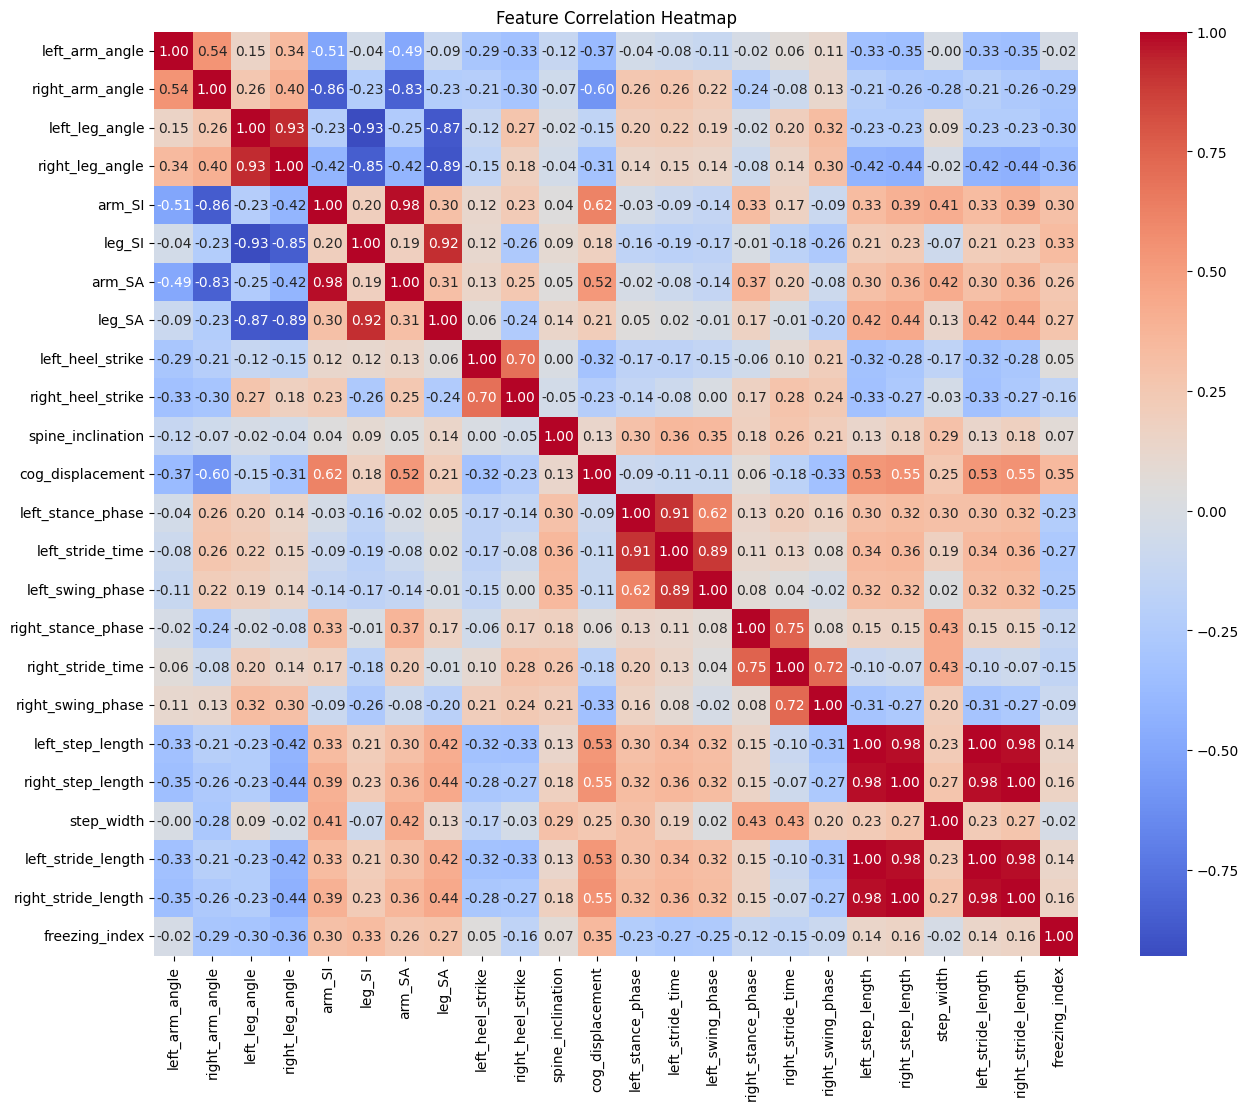

In [15]:
# heatmap of feature correlations
plt.figure(figsize=(16, 12))
corr = df_features[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [16]:
# shows min, max, overall mean, NP mean, PD mean for each features
mean_NP  = df_features[df_features['label'] == 0][FEATURE_COLS].mean()
mean_PD  = df_features[df_features['label'] == 1][FEATURE_COLS].mean()
summary_stats = df_features[FEATURE_COLS].agg(['min', 'max', 'mean']).T
summary_stats['NP_mean'] = mean_NP
summary_stats['PD_mean'] = mean_PD
display(summary_stats.round(2))

,min,max,mean,NP_mean,PD_mean
left_arm_angle,102.54,171.93,153.36,156.11,150.62
right_arm_angle,90.44,176.09,152.65,157.27,148.04
left_leg_angle,110.24,175.57,159.84,161.79,157.90
right_leg_angle,122.43,177.25,159.88,160.67,159.08
arm_SI,4.14,63.01,15.43,14.89,15.97
leg_SI,2.12,50.68,11.95,10.29,13.61
arm_SA,6.82,64.24,19.79,19.07,20.52
leg_SA,3.34,36.87,14.70,14.33,15.06
left_heel_strike,-357.35,211.86,-63.46,-103.87,-23.05
right_heel_strike,-341.28,205.15,-85.62,-105.77,-65.47


In [17]:
# Prepare 3D data (samples, timesteps, features) for LSTM models
# Group cycles by cycle count (1 to 6)

samples_3d = {n: [] for n in range(1, 7)}
labels_3d = {n: [] for n in range(1, 7)}
file_ids_3d = {n: [] for n in range(1, 7)}

print("Building non-overlapping cycle groups...")
for file_id, data in file_cycle_features.items():
    cycles_raw = data['cycles']  # List of 6 cycles, each (60, 34)
    label = data['label']
    
    for n in range(1, 7):
        # Create non-overlapping groups of n cycles
        groups = [
            cycles_raw[start:start + n]
            for start in range(0, 6, n)
            if start + n <= 6
        ]
        for group in groups:
            combined = np.concatenate(group, axis=0)  # (n*60, 34)
            samples_3d[n].append(combined)
            labels_3d[n].append(label)
            file_ids_3d[n].append(file_id)

# Convert to arrays
for n in range(1, 7):
    samples_3d[n] = np.array(samples_3d[n], dtype=np.float32)
    labels_3d[n] = np.array(labels_3d[n], dtype=int)
    file_ids_3d[n] = np.array(file_ids_3d[n])
    print(f"  {n}-cycle(s): {len(samples_3d[n])} samples, shape {samples_3d[n].shape}")


Building non-overlapping cycle groups...
  1-cycle(s): 240 samples, shape (240, 60, 34)
  2-cycle(s): 120 samples, shape (120, 120, 34)
  3-cycle(s): 80 samples, shape (80, 180, 34)
  4-cycle(s): 40 samples, shape (40, 240, 34)
  5-cycle(s): 40 samples, shape (40, 300, 34)
  6-cycle(s): 40 samples, shape (40, 360, 34)


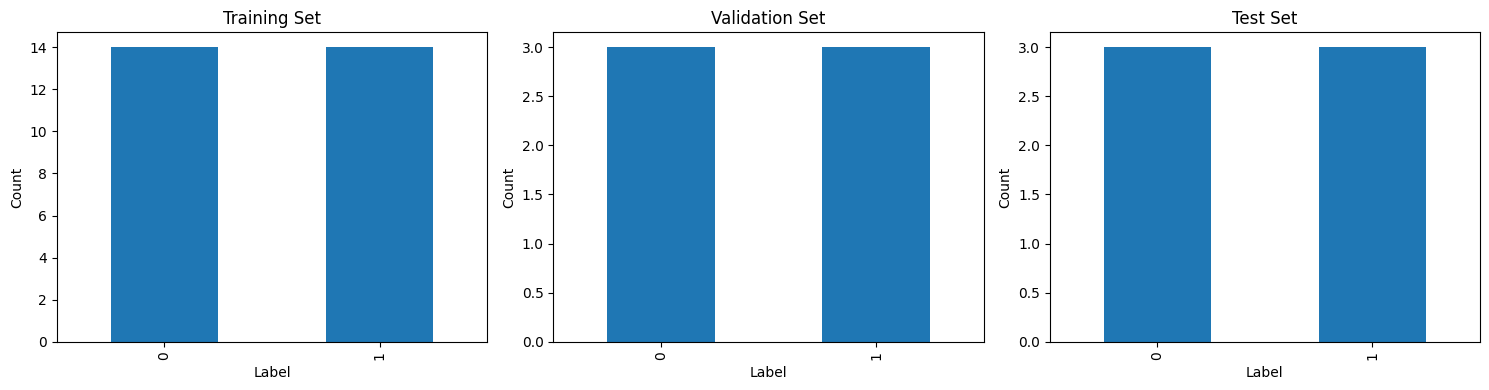

In [18]:
import matplotlib.pyplot as plt

# Create boolean masks for train/val/test sets
train_mask = df_features['file_id'].isin(train_set)
val_mask = df_features['file_id'].isin(val_set)
test_mask = df_features['file_id'].isin(test_set)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mask, title in zip(axes, [train_mask, val_mask, test_mask],
                           ['Training Set', 'Validation Set', 'Test Set']):
    counts = df_features.loc[mask, 'label'].value_counts()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

**Feature Selection**

In [19]:
# Split data by cycle count
# For each cycle count, split into train/val/test using file_ids

cycle_splits = {}
for n in range(1, 7):
    # Get indices for each set based on file_ids
    train_indices = np.where(np.isin(file_ids_3d[n], list(train_set)))[0]
    val_indices = np.where(np.isin(file_ids_3d[n], list(val_set)))[0]
    test_indices = np.where(np.isin(file_ids_3d[n], list(test_set)))[0]
    
    cycle_splits[n] = {
        'X_train': samples_3d[n][train_indices],
        'X_val': samples_3d[n][val_indices],
        'X_test': samples_3d[n][test_indices],
        'y_train': labels_3d[n][train_indices],
        'y_val': labels_3d[n][val_indices],
        'y_test': labels_3d[n][test_indices],
    }
    
    print(f"\n{n}-cycle(s) split:")
    print(f"  Train: {len(cycle_splits[n]['X_train'])} samples")
    print(f"  Val:   {len(cycle_splits[n]['X_val'])} samples")
    print(f"  Test:  {len(cycle_splits[n]['X_test'])} samples")



1-cycle(s) split:
  Train: 168 samples
  Val:   36 samples
  Test:  36 samples

2-cycle(s) split:
  Train: 84 samples
  Val:   18 samples
  Test:  18 samples

3-cycle(s) split:
  Train: 56 samples
  Val:   12 samples
  Test:  12 samples

4-cycle(s) split:
  Train: 28 samples
  Val:   6 samples
  Test:  6 samples

5-cycle(s) split:
  Train: 28 samples
  Val:   6 samples
  Test:  6 samples

6-cycle(s) split:
  Train: 28 samples
  Val:   6 samples
  Test:  6 samples


In [ ]:
# LOSO-CV evaluation pipeline
subject_table = df_features[['file_id', 'label']].drop_duplicates().sort_values('file_id').reset_index(drop=True)
logo = LeaveOneGroupOut()

all_results = []
fold_predictions_by_config = {}

print("\n" + "=" * 80)
print("MODEL DEVELOPMENT: LOSO-CV EVALUATION")
print("=" * 80)

for fold_idx, (train_idx, test_idx) in enumerate(
    logo.split(subject_table, subject_table['label'], groups=subject_table['file_id']),
    start=1,
):
    test_subject_df = subject_table.iloc[test_idx].reset_index(drop=True)
    train_subject_df = subject_table.iloc[train_idx].reset_index(drop=True)
    train_subject_df, val_subject_df = make_subject_split(
        train_subject_df,
        val_fraction=0.2,
        random_state=SEED + fold_idx,
    )

    train_subject_ids = train_subject_df['file_id'].tolist()
    val_subject_ids = val_subject_df['file_id'].tolist()
    test_subject_ids = test_subject_df['file_id'].tolist()

    fold_feature_sets = build_feature_approaches(train_subject_df)

    print(f"\n{'=' * 70}")
    print(f"FOLD {fold_idx}/{len(subject_table)} | TEST SUBJECT: {', '.join(test_subject_ids)}")
    print(f"Train subjects: {len(train_subject_ids)} | Val subjects: {len(val_subject_ids)} | Test subjects: {len(test_subject_ids)}")
    print(f"{'=' * 70}")

    for approach_name, selected_features in fold_feature_sets.items():
        print(f"\n  Approach: {approach_name} ({len(selected_features)} features)")

        for n_cycles in range(1, 7):
            X_train, y_train_fold, _ = build_cycle_dataset(train_subject_ids, n_cycles, selected_features)
            X_val, y_val_fold, _ = build_cycle_dataset(val_subject_ids, n_cycles, selected_features)
            X_test, y_test_fold, _ = build_cycle_dataset(test_subject_ids, n_cycles, selected_features)

            if X_train.size == 0 or X_val.size == 0 or X_test.size == 0:
                continue

            n_train, timesteps, n_features = X_train.shape
            scaler = StandardScaler()
            X_train_flat = X_train.reshape(-1, n_features)
            scaler.fit(X_train_flat)

            X_train_scaled = scaler.transform(X_train_flat).reshape(n_train, timesteps, n_features)
            X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
            X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

            input_shape = (timesteps, n_features)

            for model_name, model_fn in models.items():
                model = model_fn(input_shape)
                start_time = time.time()
                history = model.fit(
                    X_train_scaled,
                    y_train_fold,
                    validation_data=(X_val_scaled, y_val_fold),
                    epochs=50,
                    batch_size=16,
                    callbacks=[
                        EarlyStopping(patience=12, restore_best_weights=True),
                        ReduceLROnPlateau(patience=6, factor=0.5),
                    ],
                    verbose=0,
                )
                train_time = time.time() - start_time

                y_test_prob_fold = model.predict(X_test_scaled, verbose=0).reshape(-1)
                y_test_pred_fold = (y_test_prob_fold > 0.5).astype(int)
                metrics = compute_binary_metrics(y_test_fold, y_test_pred_fold, y_test_prob_fold)

                all_results.append(
                    {
                        'fold': fold_idx,
                        'test_subject': ','.join(test_subject_ids),
                        'approach': approach_name,
                        'cycle_size': n_cycles,
                        'model_name': model_name,
                        'n_train_samples': int(len(y_train_fold)),
                        'n_val_samples': int(len(y_val_fold)),
                        'n_test_samples': int(len(y_test_fold)),
                        'accuracy': metrics['accuracy'],
                        'precision': metrics['precision'],
                        'recall': metrics['recall'],
                        'specificity': metrics['specificity'],
                        'f1_score': metrics['f1_score'],
                        'roc_auc': metrics['roc_auc'],
                        'train_time': train_time,
                    }
                )

                config_key = (approach_name, n_cycles, model_name)
                fold_predictions_by_config.setdefault(config_key, []).append(
                    {
                        'fold': fold_idx,
                        'test_subject': ','.join(test_subject_ids),
                        'y_true': y_test_fold.astype(int),
                        'y_pred': y_test_pred_fold.astype(int),
                        'y_prob': y_test_prob_fold.astype(float),
                    }
                )

                print(
                    f"    {n_cycles}-cycle | {model_name:<20} "
                    f"Acc={metrics['accuracy']:.4f} "
                    f"Prec={metrics['precision']:.4f} "
                    f"Rec={metrics['recall']:.4f} "
                    f"Spec={metrics['specificity']:.4f} "
                    f"F1={metrics['f1_score']:.4f} "
                    f"Epochs={len(history.history['loss'])}"
                )

results_df_engineered = pd.DataFrame(all_results)
results_df_engineered.to_csv(OUTPUT_DIR / "results_validation_engineered.csv", index=False)

metric_cols = ['accuracy', 'precision', 'recall', 'specificity', 'f1_score']
summary_rows = []
for (approach_name, cycle_size, model_name), group in results_df_engineered.groupby(['approach', 'cycle_size', 'model_name']):
    row = {
        'approach': approach_name,
        'cycle_size': cycle_size,
        'model_name': model_name,
        'folds': int(len(group)),
    }
    for metric_name in metric_cols:
        row[metric_name] = format_mean_sd(group[metric_name])
    summary_rows.append(row)

cv_summary_df = pd.DataFrame(summary_rows).sort_values(['approach', 'cycle_size', 'model_name']).reset_index(drop=True)

numeric_summary = (
    results_df_engineered.groupby(['approach', 'cycle_size', 'model_name'])[metric_cols]
    .agg(['mean', 'std'])
    .reset_index()
)
numeric_summary.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in numeric_summary.columns
]

best_row = numeric_summary.sort_values(
    ['accuracy_mean', 'f1_score_mean', 'specificity_mean'],
    ascending=[False, False, False],
).iloc[0]

best_approach = best_row['approach']
best_cycle_size = int(best_row['cycle_size'])
best_model_name = best_row['model_name']
best_config_key = (best_approach, best_cycle_size, best_model_name)
best_config_results = results_df_engineered[
    (results_df_engineered['approach'] == best_approach)
    & (results_df_engineered['cycle_size'] == best_cycle_size)
    & (results_df_engineered['model_name'] == best_model_name)
].sort_values('fold').reset_index(drop=True)

best_oof_chunks = fold_predictions_by_config.get(best_config_key, [])
if best_oof_chunks:
    y_test, y_test_pred, y_test_prob = aggregate_prediction_chunks(best_oof_chunks)
else:
    y_test = np.array([], dtype=int)
    y_test_pred = np.array([], dtype=int)
    y_test_prob = np.array([], dtype=float)

test_metrics = compute_binary_metrics(y_test, y_test_pred, y_test_prob)

full_feature_sets = build_feature_approaches(subject_table)
best_selected_features = full_feature_sets[best_approach]
best_input_shape = (best_cycle_size * TIMESTEPS, len(best_selected_features))

final_train_subject_df, final_val_subject_df = make_subject_split(subject_table, val_fraction=0.2, random_state=SEED)
final_train_ids = final_train_subject_df['file_id'].tolist()
final_val_ids = final_val_subject_df['file_id'].tolist()
final_train_X, final_train_y, final_train_subjects = build_cycle_dataset(final_train_ids, best_cycle_size, best_selected_features)
final_val_X, final_val_y, final_val_subjects = build_cycle_dataset(final_val_ids, best_cycle_size, best_selected_features)

final_scaler = StandardScaler()
final_train_flat = final_train_X.reshape(-1, final_train_X.shape[-1])
final_scaler.fit(final_train_flat)
final_train_3d = final_scaler.transform(final_train_flat).reshape(final_train_X.shape)
final_val_3d = final_scaler.transform(final_val_X.reshape(-1, final_val_X.shape[-1])).reshape(final_val_X.shape)

X_train_raw = final_train_X
X_val_raw = final_val_X
y_train = final_train_y
y_val = final_val_y
X_train_flat = final_train_flat
X_train_3d = final_train_3d
X_val_3d = final_val_3d
scaler_best = final_scaler

cv_metrics_display = cv_summary_df.copy()

print("\n" + "=" * 80)
print(f"MODEL DEVELOPMENT COMPLETE: {len(results_df_engineered)} fold-level experiments")
print("=" * 80)
print("Best LOSO configuration:")
print(f"  Approach   : {best_approach}")
print(f"  Cycle Size : {best_cycle_size}")
print(f"  Model      : {best_model_name}")
print(f"  OOF Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  OOF F1     : {test_metrics['f1_score']:.4f}")
print(f"  OOF Spec   : {test_metrics['specificity']:.4f}")
print("\nFold-wise mean ± SD summary:")
display(cv_metrics_display)


Selected feature counts:
  full_features: 24 features
  correlation_filtering: 15 features
  sbs: 12 features


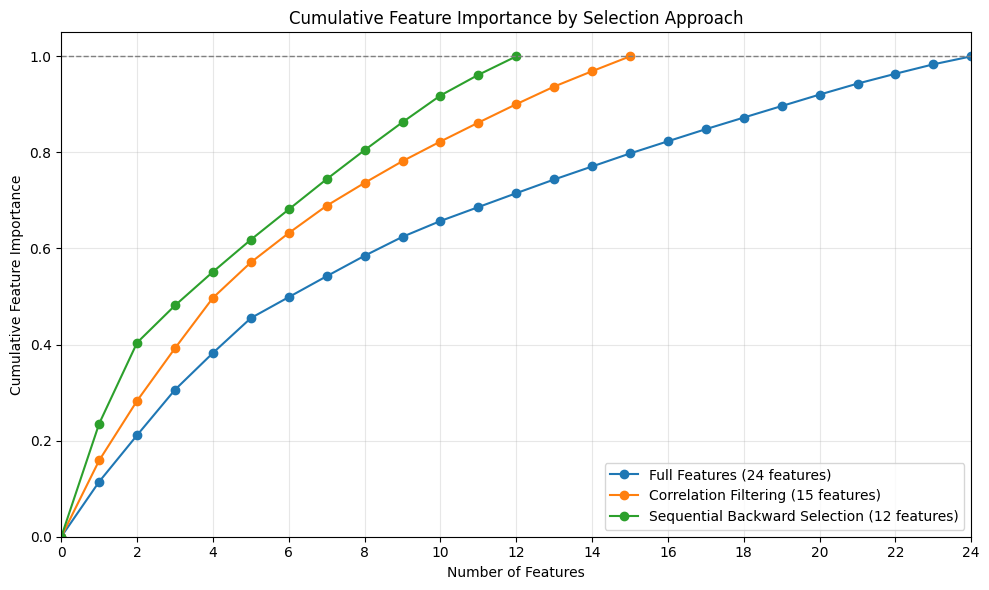

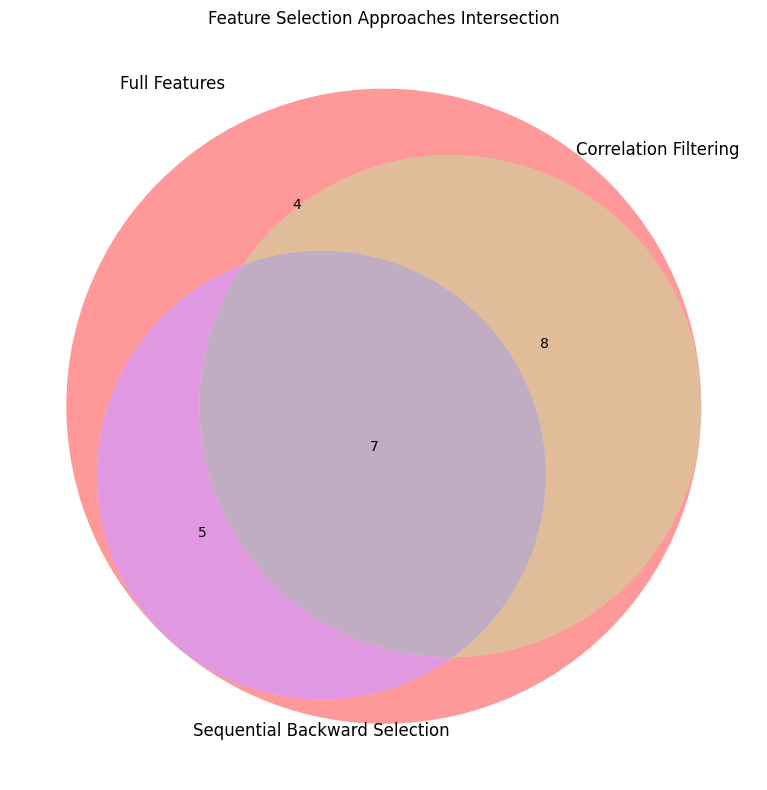


Selected features by approach:
- Full Features (24 features): ['left_arm_angle', 'right_arm_angle', 'left_leg_angle', 'right_leg_angle', 'arm_SI', 'leg_SI', 'arm_SA', 'leg_SA', 'left_heel_strike', 'right_heel_strike', 'spine_inclination', 'cog_displacement', 'left_stance_phase', 'left_stride_time', 'left_swing_phase', 'right_stance_phase', 'right_stride_time', 'right_swing_phase', 'left_step_length', 'right_step_length', 'step_width', 'left_stride_length', 'right_stride_length', 'freezing_index']
- Correlation Filtering (15 features): ['left_arm_angle', 'right_arm_angle', 'left_leg_angle', 'left_heel_strike', 'right_heel_strike', 'spine_inclination', 'cog_displacement', 'left_stance_phase', 'left_swing_phase', 'right_stance_phase', 'right_stride_time', 'right_swing_phase', 'left_step_length', 'step_width', 'freezing_index']
- Sequential Backward Selection (12 features): ['leg_SI', 'spine_inclination', 'cog_displacement', 'left_stride_time', 'right_stride_time', 'right_swing_phase', 'l

In [21]:
# Cumulative feature importance plot and feature set intersections
from matplotlib_venn import venn3

plot_approaches = {
    'Full Features': approaches['full_features'],
    'Correlation Filtering': approaches['correlation_filtering'],
    'Sequential Backward Selection': approaches['sbs']
}

max_len = max(len(d['selected_features']) for d in plot_approaches.values()) or 1

plt.figure(figsize=(10, 6))
for approach_name, data in plot_approaches.items():
    X_train_approach = data['X_train']
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train_approach, y_train_fs)
    
    importances = model.feature_importances_
    sorted_importances = np.sort(importances)[::-1]
    cumulative_importances = np.cumsum(sorted_importances)
    
    # prepend 0 so curves start at 0 features with 0 importance
    cum_with_zero = np.concatenate(([0.0], cumulative_importances))
    x_with_zero = np.arange(0, len(cum_with_zero))
    
    plt.plot(
        x_with_zero,
        cum_with_zero,
        marker='o',
        label=f"{approach_name} ({len(data['selected_features'])} features)"
    )

# add dashed horizontal line at 1.0
plt.axhline(y=1.0, linestyle='--', color='gray', linewidth=1)
plt.ylim(0, 1.05)
plt.xlim(0, max_len)
step = max(1, max_len // 10)
plt.xticks(np.arange(0, max_len + 1, step))
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Feature Importance")
plt.title("Cumulative Feature Importance by Selection Approach")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# visualization of intersection of selected features across approaches
sets = {
    'Full Features': set(approaches['full_features']['selected_features']),
    'Correlation Filtering': set(approaches['correlation_filtering']['selected_features']),
    'Sequential Backward Selection': set(approaches['sbs']['selected_features'])
}
plt.figure(figsize=(8, 8))
venn3(sets.values(), sets.keys())
plt.title("Feature Selection Approaches Intersection")
plt.tight_layout()
plt.show()

print("\nSelected features by approach:")
for approach_name, data in plot_approaches.items():
    feats = data['selected_features']
    print(f"- {approach_name} ({len(feats)} features): {feats}")

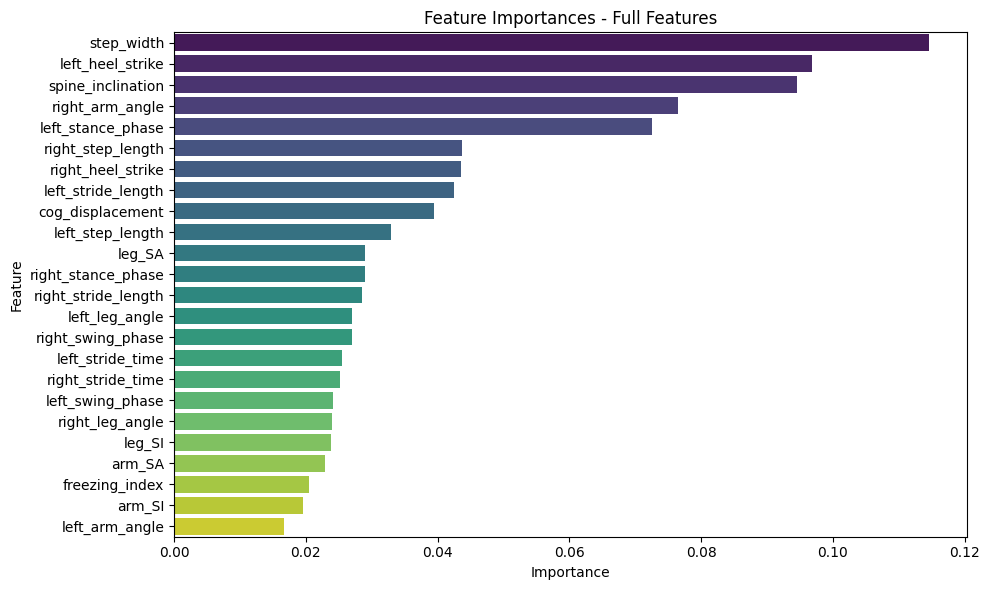

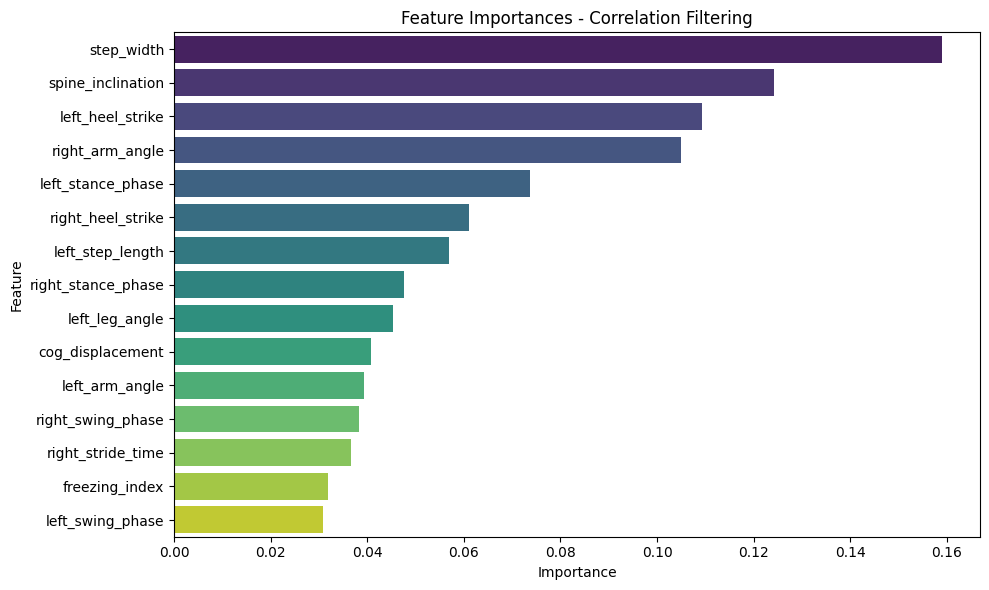

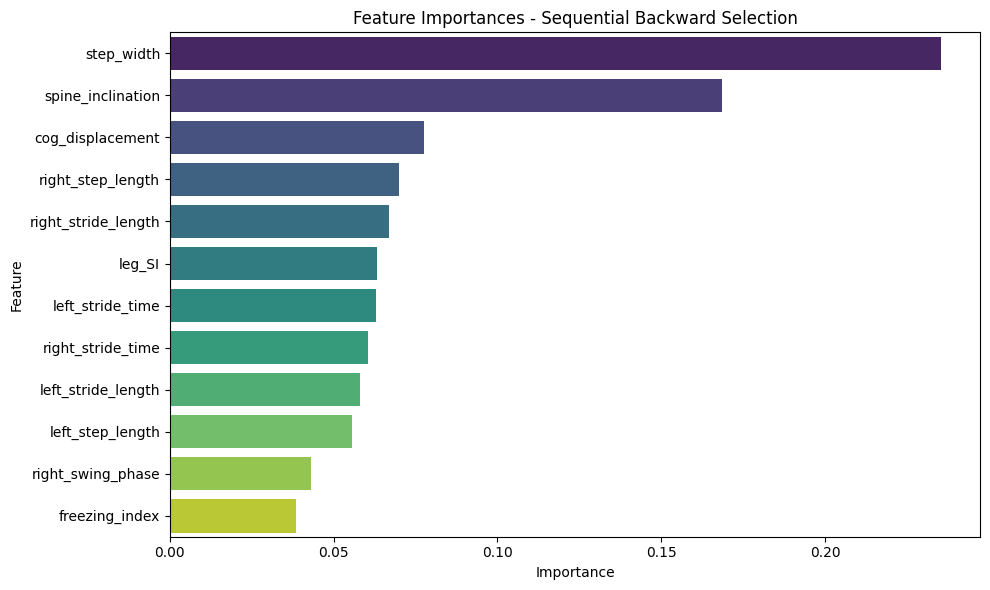

In [22]:
# features importance visualization
for approach_name, data in plot_approaches.items():
    X_train_approach = data['X_train']
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train_approach, y_train_fs)
    
    importances = model.feature_importances_
    feature_names = data['selected_features']
    
    feat_imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=feat_imp_df,  palette='viridis')
    plt.title(f"Feature Importances - {approach_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [23]:
# Precompute 3D feature sequences for all feature selection approaches
# 6 arrays of shape (60, len(FEATURE_COLS)), with columns in FEATURE_COLS order.

approach_splits = {}
# Create a mapping from feature name to its column index in the per-frame data
feature_to_idx = {name: idx for idx, name in enumerate(FEATURE_COLS)}
df_features_by_id = df_features.set_index('file_id')  # still kept for safety, though unused

print("Building 3D feature sequences for each approach...")
for app_name, app_data in approaches.items():
    selected_cols = app_data['selected_features']
    
    # Get column indices for selected features
    selected_indices = [feature_to_idx[col] for col in selected_cols]

    samples_3d = {n: [] for n in range(1, 7)}
    labels_3d = {n: [] for n in range(1, 7)}
    file_ids_3d = {n: [] for n in range(1, 7)}

    for file_id, data in file_cycle_feature_seqs.items():
        cycles = data['cycles']  # list of 6 × (60, len(FEATURE_COLS))
        label = data['label']

        for n in range(1, 7):
            for start in range(0, 6, n):
                if start + n <= 6:
                    group = cycles[start:start + n]  # n cycles
                    stacked = np.concatenate(group, axis=0)  # (n*60, len(FEATURE_COLS))
                    
                    # Select only the chosen feature columns
                    combined = stacked[:, selected_indices]  # (n*60, len(selected_cols))
                    
                    samples_3d[n].append(combined)
                    labels_3d[n].append(label)
                    file_ids_3d[n].append(file_id)

    # Convert to arrays
    for n in range(1, 7):
        if samples_3d[n]:  # avoid empty
            samples_3d[n] = np.array(samples_3d[n], dtype=np.float32)
            labels_3d[n] = np.array(labels_3d[n], dtype=int)
            file_ids_3d[n] = np.array(file_ids_3d[n])
        else:
            D = len(selected_cols)
            samples_3d[n] = np.empty((0, 0, D), dtype=np.float32)
            labels_3d[n] = np.array([])
            file_ids_3d[n] = np.array([])

    # Split into train/val/test by file_id
    cycle_splits_app = {}
    for n in range(1, 7):
        train_idx = np.where(np.isin(file_ids_3d[n], list(train_set)))[0]
        val_idx = np.where(np.isin(file_ids_3d[n], list(val_set)))[0]
        test_idx = np.where(np.isin(file_ids_3d[n], list(test_set)))[0]

        cycle_splits_app[n] = {
            'X_train': samples_3d[n][train_idx],
            'X_val': samples_3d[n][val_idx],
            'X_test': samples_3d[n][test_idx],
            'y_train': labels_3d[n][train_idx],
            'y_val': labels_3d[n][val_idx],
            'y_test': labels_3d[n][test_idx],
        }

    approach_splits[app_name] = cycle_splits_app
    example_shape = cycle_splits_app[1]['X_train'].shape if len(cycle_splits_app[1]['X_train']) > 0 else "(empty)"
    print(f"  {app_name}: using {len(selected_cols)} features; example shape {example_shape}")

print(f"\nTotal approaches ready for LSTM training: {len(approach_splits)}")

Building 3D feature sequences for each approach...
  full_features: using 24 features; example shape (168, 60, 24)
  correlation_filtering: using 15 features; example shape (168, 60, 15)
  sbs: using 12 features; example shape (168, 60, 12)

Total approaches ready for LSTM training: 3


**Model Development**

In [24]:
class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(1,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        # x: (batch, timesteps, features)
        e = tf.tanh(tf.matmul(x, self.W) + self.b)  # (batch, timesteps, 1)
        a = tf.nn.softmax(e, axis=1)               # (batch, timesteps, 1)
        return tf.reduce_sum(x * a, axis=1)        # (batch, features)

    def get_config(self):
        config = super().get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

def evaluation_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred)
    }

def lstm_baseline(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    x = LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(16, dropout=0.3, recurrent_dropout=0.2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_bidirectional(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(12, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_simpleatt(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(12, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    attention_output = SimpleAttention()(x)
    outputs = Dense(1, activation='sigmoid')(attention_output)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def lstm_multiheadatt(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs 
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(16, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    attention_output = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    pooled = GlobalAveragePooling1D()(attention_output)
    pooled = Dropout(0.3)(pooled)
    outputs = Dense(1, activation='sigmoid')(pooled)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = {
    'lstm_baseline': lstm_baseline,
    'lstm_bidirectional': lstm_bidirectional,
    'lstm_simpleatt': lstm_simpleatt,
    'lstm_multiheadatt': lstm_multiheadatt
}

**Model Training**

In [25]:
all_results = []

print("\n" + "="*80)
print("MODEL DEVELOPMENT: VALIDATION-BASED TRAINING")
print("="*80)

for approach_name, cycle_splits in approach_splits.items():

    print(f"\n{'='*70}")
    print(f"APPROACH: {approach_name}")
    print(f"{'='*70}")

    for n_cycles in range(1, 7):

        print(f"\n → {n_cycles}-cycle input")

        # -------------------------------
        # Load TRAIN / VAL data
        # -------------------------------
        X_train = cycle_splits[n_cycles]['X_train']
        X_val   = cycle_splits[n_cycles]['X_val']
        y_train = cycle_splits[n_cycles]['y_train']
        y_val   = cycle_splits[n_cycles]['y_val']

        N, T, F = X_train.shape

        # -------------------------------
        # Scaling (FIT ON TRAIN ONLY)
        # -------------------------------
        scaler = StandardScaler()

        X_train_flat = X_train.reshape(-1, F)
        scaler.fit(X_train_flat)

        X_train_scaled = scaler.transform(X_train_flat).reshape(N, T, F)
        X_val_scaled   = scaler.transform(
            X_val.reshape(-1, F)
        ).reshape(X_val.shape)

        # Save scaler for this configuration
        scaler_path = OUTPUT_DIR / f"scaler_{approach_name}_{n_cycles}cycle.pkl"
        with open(scaler_path, "wb") as f:
            pickle.dump(scaler, f)

        input_shape = (T, F)

        # -------------------------------
        # Train all models
        # -------------------------------
        for model_name, model_fn in models.items():

            print(f"    Training {model_name} | input={input_shape}")

            model = model_fn(input_shape)

            start_time = time.time()

            history = model.fit(
                X_train_scaled, y_train,
                validation_data=(X_val_scaled, y_val),
                epochs=50,
                batch_size=16,
                callbacks=[
                    EarlyStopping(patience=12, restore_best_weights=True),
                    ReduceLROnPlateau(patience=6, factor=0.5)
                ],
                verbose=0
            )

            train_time = time.time() - start_time

            # -------------------------------
            # Validation Evaluation
            # -------------------------------
            y_val_prob = model.predict(X_val_scaled, verbose=0)
            y_val_pred = (y_val_prob > 0.5).astype(int).flatten()

            metrics = evaluation_metrics(y_val, y_val_pred)

            val_loss = tf.keras.losses.binary_crossentropy(
                y_val, y_val_prob.flatten()
            ).numpy().mean()

            # -------------------------------
            # Save results
            # -------------------------------
            all_results.append({
                "approach": approach_name,
                "cycle_size": n_cycles,
                "model_name": model_name,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1_score": metrics["f1_score"],
                "roc_auc": metrics["roc_auc"],
                "val_loss": val_loss,
                "train_time": train_time
            })

            print(
                f"      Val Acc={metrics['accuracy']:.4f} | "
                f"Val Loss={val_loss:.4f} | "
                f"Epochs={len(history.history['loss'])}"
            )

results_df_engineered = pd.DataFrame(all_results)

print("\n" + "="*80)
print(f"MODEL DEVELOPMENT COMPLETE: {len(results_df_engineered)} experiments")
print("="*80)

results_df_engineered.to_csv(
    OUTPUT_DIR / "results_validation_engineered.csv",
    index=False
)


MODEL DEVELOPMENT: VALIDATION-BASED TRAINING

APPROACH: full_features

 → 1-cycle input
    Training lstm_baseline | input=(60, 24)
      Val Acc=0.6389 | Val Loss=0.5840 | Epochs=26
    Training lstm_bidirectional | input=(60, 24)
      Val Acc=0.7500 | Val Loss=0.4648 | Epochs=40
    Training lstm_simpleatt | input=(60, 24)

      Val Acc=0.7500 | Val Loss=0.5420 | Epochs=29
    Training lstm_multiheadatt | input=(60, 24)
      Val Acc=0.6111 | Val Loss=0.5438 | Epochs=23

 → 2-cycle input
    Training lstm_baseline | input=(120, 24)
      Val Acc=0.6667 | Val Loss=0.6174 | Epochs=38
    Training lstm_bidirectional | input=(120, 24)
      Val Acc=0.6111 | Val Loss=0.6019 | Epochs=50
    Training lstm_simpleatt | input=(120, 24)
      Val Acc=0.8333 | Val Loss=0.4552 | Epochs=44
    Training lstm_multiheadatt | input=(120, 24)
      Val Acc=0.6111 | Val Loss=0.5470 | Epochs=39

 → 3-cycle input
    Training lstm_baseline | input=(180, 24)
      Val Acc=0.7500 | Val Loss=0.6206 | Epoc

In [ ]:
# visualize the model architectures using model.summary()
input_shape = best_input_shape

for model_name, model_func in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)
    model_instance = model_func(input_shape)
    model_instance.summary()
    print('\n')


Model: lstm_baseline


Model: "functional_72"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_72 (InputLayer)     │ (None, 360, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_144 (LSTM)                 │ (None, 360, 32)        │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_144         │ (None, 360, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_180 (Dropout)           │ (None, 360, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_145 (LSTM)                 │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_145         │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_181 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,105 (35.57 KB)

 Trainable params: 9,009 (35.19 KB)

...

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_75      │ (None, 360, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_112   │ (None, 360, 48)   │      7,104 │ input_layer_75[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 48)   │        192 │ bidirectional_11… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_186         │ (None, 360, 48)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_113   │ (None, 360, 32)   │      8,320 │ dropout_186[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ bidirectional_11… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_187         │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 360, 32)   │      4,224 │ dropout_187[0][0… │
│ (MultiHeadAttentio… │                   │            │ dropout_187[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_189         │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 1)         │         33 │ dropout_189[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 19,841 (77.50 KB)

 Non-trainable params: 160 (640.00 B)

In [ ]:
print("Final refit train shape:", X_train_raw.shape)
print("Final refit val shape:", X_val_raw.shape)
print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_val.shape)
print("Best LOSO configuration:")
print(f"  Approach   : {best_approach}")
print(f"  Cycle Size : {best_cycle_size}")
print(f"  Model      : {best_model_name}")
print(f"  Input Shape: {best_input_shape}")

X_train_flat shape: (10080, 12)
y_train shape: (28,)
X_val shape: (6, 360, 12)
y_val shape: (6,)


**Select Best Feature Selection Method**

In [28]:
# Summary table: average accuracy vs feature selection approach
results_df_engineered = pd.read_csv(OUTPUT_DIR / "results_validation_engineered.csv")
summary_table = results_df_engineered.groupby('approach')['accuracy'].mean().reset_index()
print("\nAverage Accuracy by Feature Selection Approach:")
print(summary_table.round(4))


Average Accuracy by Feature Selection Approach:
                approach  accuracy
0  correlation_filtering    0.7106
1          full_features    0.7106
2                    sbs    0.7083


**Select Best Cycle**

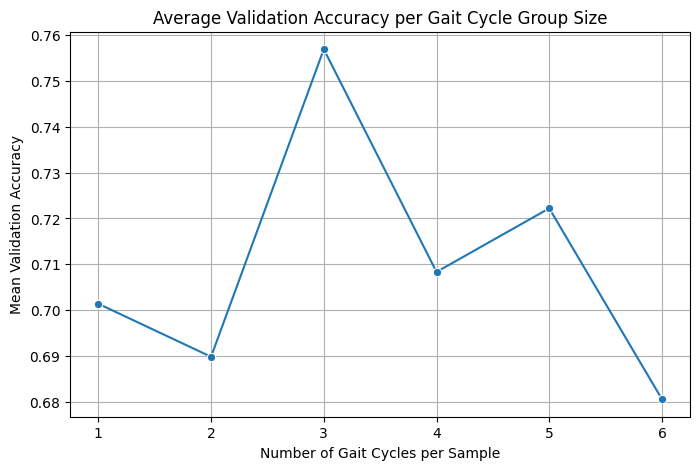

Best cycle size based on validation accuracy: 3


In [29]:
# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Compute mean accuracy per cycle size
mean_results = results_df.groupby('cycle_size')['accuracy'].mean().reset_index()

# Plot mean accuracy vs cycle size
plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_results, x='cycle_size', y='accuracy', marker='o')
plt.title("Average Validation Accuracy per Gait Cycle Group Size")
plt.xlabel("Number of Gait Cycles per Sample")
plt.ylabel("Mean Validation Accuracy")
plt.grid()
plt.show()

# Select best cycle size based on feature selection approach
best_cycle_size = mean_results.loc[mean_results['accuracy'].idxmax(), 'cycle_size']
print(f"Best cycle size based on validation accuracy: {best_cycle_size}")

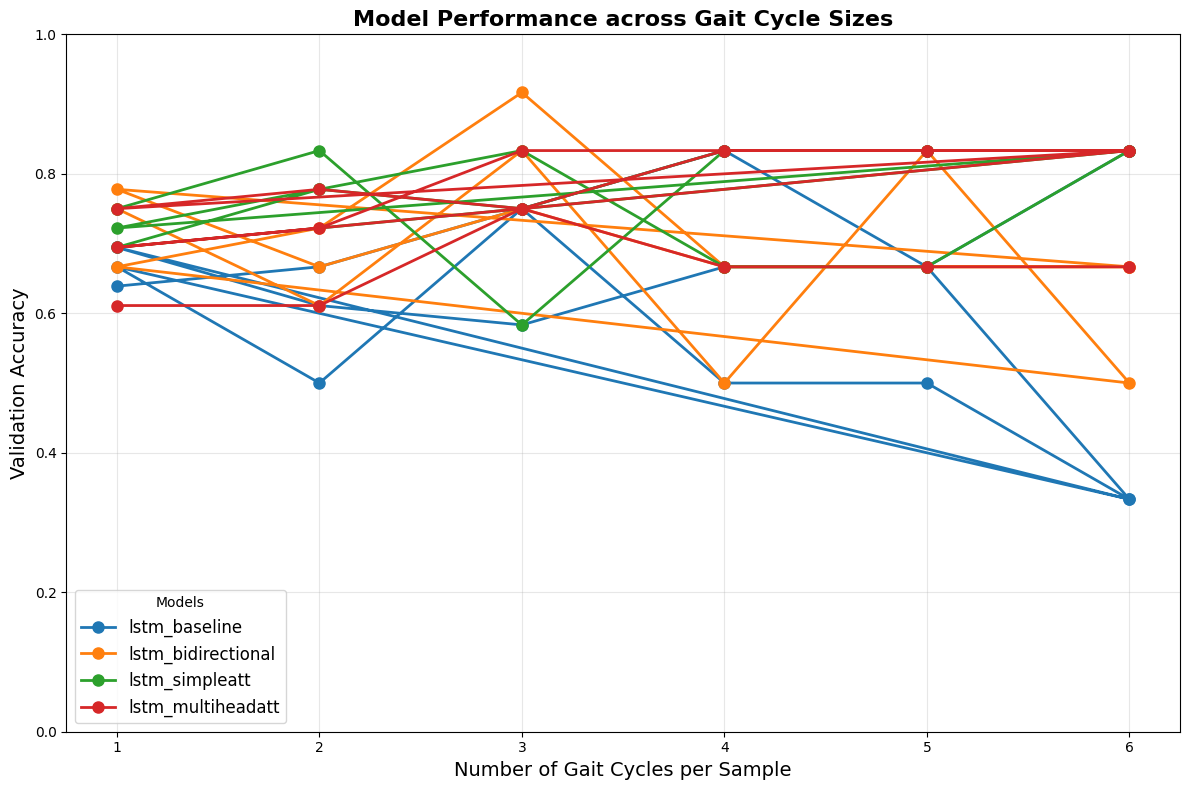

In [30]:
plt.figure(figsize=(12, 8))

# Get unique model names and assign colors
model_names = results_df['model_name'].unique()
colors = sns.color_palette('tab10', n_colors=len(model_names))

# Plot each model's accuracy across cycle sizes
for i, model in enumerate(model_names):
    subset = results_df[results_df['model_name'] == model]
    plt.plot(
        subset['cycle_size'],
        subset['accuracy'],
        marker='o',
        linewidth=2,
        markersize=8,
        color=colors[i],
        label=model
    )

plt.xlabel('Number of Gait Cycles per Sample', fontsize=14)
plt.ylabel('Validation Accuracy', fontsize=14)
plt.title('Model Performance across Gait Cycle Sizes', fontsize=16, fontweight='bold')
plt.xticks(sorted(results_df['cycle_size'].unique()))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='Models', fontsize=12)
plt.tight_layout()

plt.show()

In [31]:
# Summary table: accuracy vs cycle size for every approach
summary = results_df_engineered.pivot_table(index='cycle_size', columns='approach', values='accuracy', aggfunc='mean')
print("Validation Accuracy by Cycle Size and Approach:")
display(summary)

Validation Accuracy by Cycle Size and Approach:


approach,correlation_filtering,full_features,sbs
cycle_size,,,
1,0.687500,0.687500,0.729167
2,0.680556,0.680556,0.708333
3,0.812500,0.729167,0.729167
4,0.708333,0.750000,0.666667
5,0.708333,0.791667,0.666667
6,0.666667,0.625000,0.750000


**Select Best Model**

In [32]:
# summary of each cyle size with respective models based on feature approach
summary = results_df_engineered.pivot_table(
    index=['approach', 'cycle_size'],
    columns='model_name',
    values='accuracy',
    aggfunc='mean'
).round(4)

print("Validation Accuracy Matrix (Cycle Size × Model):")
display(summary)

Validation Accuracy Matrix (Cycle Size × Model):


model_name                        lstm_baseline  lstm_bidirectional  \
approach              cycle_size                                      
correlation_filtering 1                  0.6667              0.6667   
                      2                  0.5000              0.7222   
                      3                  0.7500              0.9167   
                      4                  0.5000              0.6667   
                      5                  0.5000              0.6667   
                      6                  0.3333              0.6667   
full_features         1                  0.6389              0.7500   
                      2                  0.6667              0.6111   
                      3                  0.7500              0.8333   
                      4                  0.8333              0.5000   
                      5                  0.6667              0.8333   
                      6                  0.3333              0.5000   
sbs                   1                  0.6944              0.7778   
                      2                  0.6111              0.6667   
                      3                  0.5833              0.7500   
                      4                  0.6667              0.6667   
                      5                  0.6667              0.6667   
                      6                  0.8333              0.6667   

model_name                        lstm_multiheadatt  lstm_simpleatt  
approach              cycle_size                                     
correlation_filtering 1                      0.6944          0.7222  
                      2                      0.7222          0.7778  
                      3                      0.8333          0.7500  
                      4                      0.8333          0.8333  
                      5                      0.8333          0.8333  
                      6                      0.8333          0.8333  
full_features         1                      0.6111          0.7500  
                      2                      0.6111          0.8333  
                      3                      0.7500          0.5833  
                      4                      0.8333          0.8333  
                      5                      0.8333          0.8333  
                      6                      0.8333          0.8333  
sbs                   1                      0.7500          0.6944  
                      2                      0.7778          0.7778  
                      3                      0.7500          0.8333  
                      4                      0.6667          0.6667  
                      5                      0.6667          0.6667  
                      6                      0.6667          0.8333

In [33]:
# summary of evaluation metrics for each models with average cycles accuracy, precision, recall, f1_score, roc_auc
metrics_summary = results_df_engineered.pivot_table(
    index='model_name',
    values=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'],
    aggfunc='mean'
).round(4)

print("Evaluation Metrics Summary:")
display(metrics_summary)

Evaluation Metrics Summary:


,accuracy,f1_score,precision,recall,roc_auc
model_name,,,,,
lstm_baseline,0.6219,0.5798,0.6356,0.5556,0.6219
lstm_bidirectional,0.6960,0.6603,0.7113,0.6481,0.6960
lstm_multiheadatt,0.7500,0.6883,0.9050,0.5772,0.7500
lstm_simpleatt,0.7716,0.7207,0.9157,0.6080,0.7716


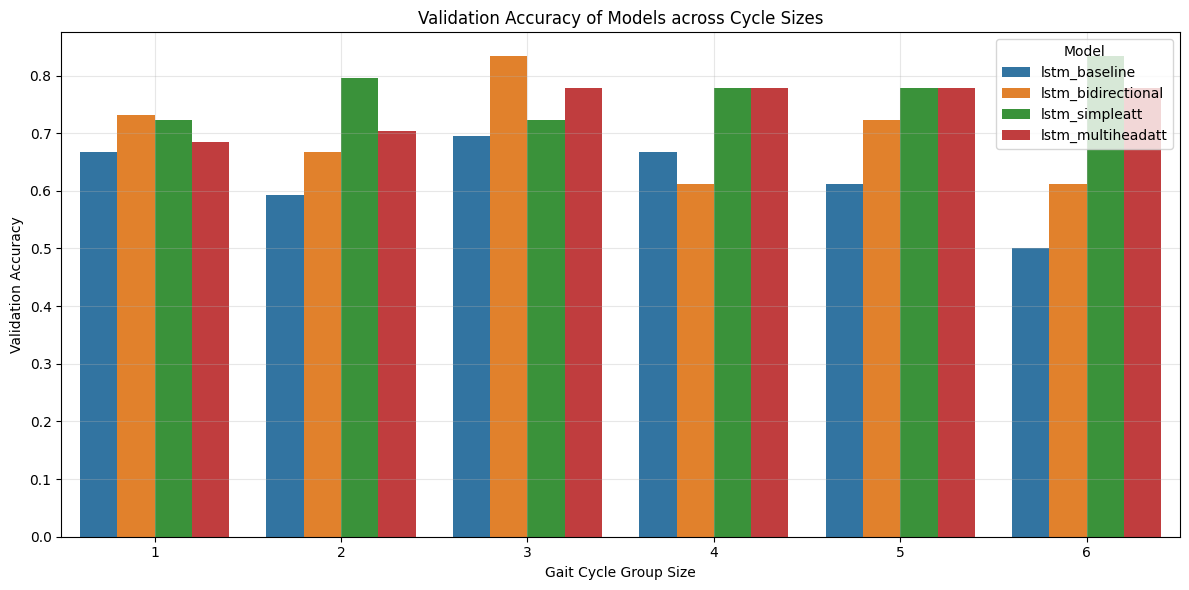

In [34]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=results_df_engineered, x='cycle_size', y='accuracy', hue='model_name', ci=None)

plt.title('Validation Accuracy of Models across Cycle Sizes')
plt.xlabel('Gait Cycle Group Size')
plt.ylabel('Validation Accuracy')
plt.legend(title='Model')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Find Best Configuration**

In [ ]:
# Train the best model on the final subject-independent refit split
print("Loading final refit data...")

X_train_raw = final_train_X
X_val_raw = final_val_X
y_train = final_train_y
y_val = final_val_y

print(f"Train data shape: {X_train_raw.shape}")
print(f"Val data shape: {X_val_raw.shape}")

scaler_best = final_scaler
X_train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
X_train_3d = scaler_best.transform(X_train_flat).reshape(X_train_raw.shape)
X_val_3d = scaler_best.transform(X_val_raw.reshape(-1, X_val_raw.shape[-1])).reshape(X_val_raw.shape)

print(f"Data scaled using scaler fitted on {X_train_flat.shape[1]} features")

input_shape = (X_train_3d.shape[1], X_train_3d.shape[2])
model_best = models[best_model_name](input_shape)
model_best.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\nTraining {best_model_name} on final refit split...")
history = model_best.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=12, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=6)
    ],
    verbose=1
)

os.makedirs(OUTPUT_DIR / "results", exist_ok=True)
model_save_path = OUTPUT_DIR / f"results/{best_approach}_{best_model_name}_{best_cycle_size}cycles.weights.h5"
scaler_save_path = OUTPUT_DIR / f"results/{best_approach}_{best_model_name}_{best_cycle_size}cycles_scaler.pkl"

model_best.save_weights(str(model_save_path))
joblib.dump(scaler_best, str(scaler_save_path))

print(f"Model weights saved to: {model_save_path}")
print(f"Scaler saved to: {scaler_save_path}")


BEST VALIDATION CONFIGURATION
----------------------------------------
Approach   : correlation_filtering
Cycle Size : 3
Model      : lstm_bidirectional
Val Acc    : 0.9167


In [36]:
# Load data and build best model
print("Loading best configuration data...")

# Load train, val, and test data from the best approach and cycle size
X_train_raw = approach_splits[best_approach][best_cycle_size]['X_train']
X_val_raw = approach_splits[best_approach][best_cycle_size]['X_val']
y_train = approach_splits[best_approach][best_cycle_size]['y_train']
y_val = approach_splits[best_approach][best_cycle_size]['y_val']

print(f"Train data shape: {X_train_raw.shape}")
print(f"Val data shape: {X_val_raw.shape}")

# Create and fit scaler on training data of the best configuration
scaler_best = StandardScaler()
X_train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
scaler_best.fit(X_train_flat)

# Transform train, val, and test data
X_train_3d = scaler_best.transform(X_train_flat).reshape(X_train_raw.shape)
X_val_3d = scaler_best.transform(X_val_raw.reshape(-1, X_val_raw.shape[-1])).reshape(X_val_raw.shape)

print(f"Data scaled using scaler fitted on {X_train_flat.shape[1]} features")

# Build and train the best model
input_shape = (X_train_3d.shape[1], X_train_3d.shape[2])
model_best = models[best_model_name](input_shape)

# Compile the model
model_best.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\nTraining {best_model_name} on best configuration...")
history = model_best.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[
        EarlyStopping(patience=12, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=6)
    ],
    verbose=1
)

# Save the best model and scaler
os.makedirs(OUTPUT_DIR / "results", exist_ok=True)
model_save_path = OUTPUT_DIR / f"results/{best_approach}_{best_model_name}_{best_cycle_size}cycles.weights.h5"
scaler_save_path = OUTPUT_DIR / f"results/{best_approach}_{best_model_name}_{best_cycle_size}cycles_scaler.pkl"

model_best.save_weights(str(model_save_path))
joblib.dump(scaler_best, str(scaler_save_path))
    
print(f"Model weights saved to: {model_save_path}")
print(f"Scaler saved to: {scaler_save_path}")

Loading best configuration data...
Train data shape: (56, 180, 15)
Val data shape: (12, 180, 15)
Data scaled using scaler fitted on 15 features

Training lstm_bidirectional on best configuration...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 825ms/step - accuracy: 0.4643 - loss: 0.9336 - val_accuracy: 0.4167 - val_loss: 0.7123 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.5714 - loss: 0.8948 - val_accuracy: 0.4167 - val_loss: 0.7045 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.5893 - loss: 0.7030 - val_accuracy: 0.4167 - val_loss: 0.6978 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.6429 - loss: 0.7349 - val_accuracy: 0.3333 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.6429 - loss: 0.6880 - val_accuracy: 0.3333 - val_loss: 0.6858 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step -

Generating validation predictions...
X_val_3d shape: (12, 180, 15)
y_val shape: (12,)
y_val_prob shape: (12, 1)
y_val_pred shape after conversion: (12,)
y_val_pred: [0 0 0 0 0 1 1 1 1 1 0 1]


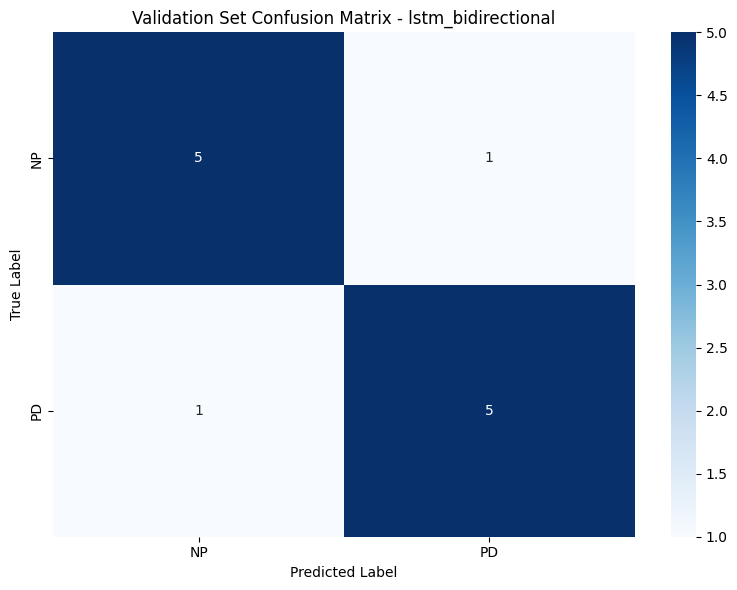


Validation Set Shapes:
y_val: (12,)
y_val_pred: (12,)


In [37]:
# Generate validation predictions
print(f"Generating validation predictions...")
print(f"X_val_3d shape: {X_val_3d.shape}")
print(f"y_val shape: {y_val.shape}")

y_val_prob = model_best.predict(X_val_3d, verbose=0)
print(f"y_val_prob shape: {y_val_prob.shape}")

# Flatten predictions properly
if len(y_val_prob.shape) > 1 and y_val_prob.shape[1] == 1:
    y_val_pred = (y_val_prob[:, 0] > 0.5).astype(int)
else:
    y_val_pred = (y_val_prob > 0.5).astype(int).flatten()

print(f"y_val_pred shape after conversion: {y_val_pred.shape}")
print(f"y_val_pred: {y_val_pred}")

# Confusion matrix visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NP', 'PD'], yticklabels=['NP', 'PD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Validation Set Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print(f"\nValidation Set Shapes:")
print(f"y_val: {y_val.shape}")
print(f"y_val_pred: {y_val_pred.shape}")

In [ ]:
import joblib

# Save the trained final model and scaler
save_path = OUTPUT_DIR / f"best_model_{best_model_name}_{best_cycle_size}cycles.h5"
model_best.save(str(save_path))
joblib.dump(scaler_best, str(OUTPUT_DIR / f"scaler_{best_cycle_size}cycles.pkl"))
print(f"Saved model to {save_path} and scaler to {OUTPUT_DIR / f'scaler_{best_cycle_size}cycles.pkl'}")

Saved model to models\full_features\best_model_lstm_bidirectional_3cycles.h5 and scaler to models\full_features\scaler_3cycles.pkl


**Final Test Evaluation**

In [ ]:
# Report the out-of-fold LOSO predictions for the selected configuration
print(f"Out-of-fold samples: {len(y_test)}")
print(f"y_test shape: {y_test.shape}")
print(f"y_test_pred shape: {y_test_pred.shape}")
print(f"y_test_prob shape: {y_test_prob.shape}")

print(f"\n{'='*60}")
print(f"OUT-OF-FOLD PERFORMANCE")
print(f"{'='*60}")
for metric_name, value in test_metrics.items():
    print(f"{metric_name:20}: {value:.4f}")
print(f"{'='*60}\n")

Test data shape: (12, 180, 15)
Data scaled using scaler fitted on 15 features

TEST SET PERFORMANCE
accuracy            : 0.4167
precision           : 0.4286
recall              : 0.5000
f1_score            : 0.4615
roc_auc             : 0.4167



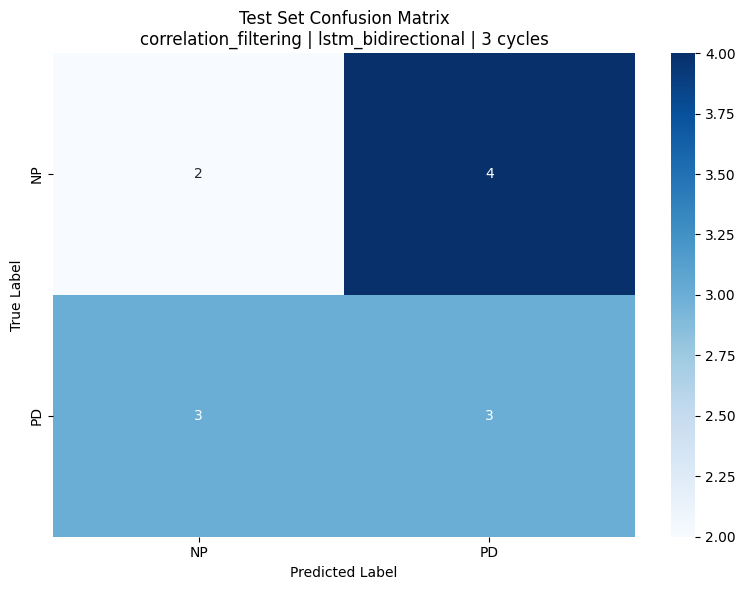


Detailed Classification Report:
              precision    recall  f1-score   support

          NP       0.40      0.33      0.36         6
          PD       0.43      0.50      0.46         6

    accuracy                           0.42        12
   macro avg       0.41      0.42      0.41        12
weighted avg       0.41      0.42      0.41        12



In [ ]:
# Visualize confusion matrix for the out-of-fold LOSO predictions
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NP', 'PD'], yticklabels=['NP', 'PD'])
plt.title(f'LOSO Out-of-Fold Confusion Matrix\n{best_approach} | {best_model_name} | {best_cycle_size} cycles')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['NP', 'PD'], zero_division=0))

In [ ]:
# Save the out-of-fold LOSO predictions and metrics
fold_results = results_df_engineered[
    (results_df_engineered['approach'] == best_approach)
    & (results_df_engineered['cycle_size'] == best_cycle_size)
    & (results_df_engineered['model_name'] == best_model_name)
].sort_values('fold').reset_index(drop=True)

test_results = {
    'approach': best_approach,
    'model_name': best_model_name,
    'cycle_size': best_cycle_size,
    'y_test': y_test,
    'y_test_pred': y_test_pred,
    'y_test_prob': y_test_prob,
    'metrics': test_metrics,
    'fold_results': fold_results,
}

results_path = OUTPUT_DIR / f"results/test_results_{best_approach}_{best_model_name}_{best_cycle_size}cycles.pkl"
with open(results_path, 'wb') as f:
    pickle.dump(test_results, f)

print(f"Out-of-fold results saved to: {results_path}")

Test results saved to: models\full_features\results\test_results_correlation_filtering_lstm_bidirectional_3cycles.pkl


In [ ]:
# Paired statistical tests from LOSO fold results
ranking = numeric_summary.sort_values(
    ['accuracy_mean', 'f1_score_mean', 'specificity_mean'],
    ascending=[False, False, False],
).reset_index(drop=True)

if len(ranking) >= 2:
    top_a = ranking.iloc[0]
    top_b = ranking.iloc[1]

    key_a = (top_a['approach'], int(top_a['cycle_size']), top_a['model_name'])
    key_b = (top_b['approach'], int(top_b['cycle_size']), top_b['model_name'])

    fold_a = results_df_engineered[
        (results_df_engineered['approach'] == key_a[0])
        & (results_df_engineered['cycle_size'] == key_a[1])
        & (results_df_engineered['model_name'] == key_a[2])
    ][['fold', 'accuracy']].rename(columns={'accuracy': 'accuracy_a'})

    fold_b = results_df_engineered[
        (results_df_engineered['approach'] == key_b[0])
        & (results_df_engineered['cycle_size'] == key_b[1])
        & (results_df_engineered['model_name'] == key_b[2])
    ][['fold', 'accuracy']].rename(columns={'accuracy': 'accuracy_b'})

    paired_folds = fold_a.merge(fold_b, on='fold', how='inner')

    if len(paired_folds) >= 2 and not np.allclose(paired_folds['accuracy_a'], paired_folds['accuracy_b']):
        wilcoxon_stat, wilcoxon_p = wilcoxon(paired_folds['accuracy_a'], paired_folds['accuracy_b'])
    else:
        wilcoxon_stat, wilcoxon_p = 0.0, 1.0

    y_true_a, y_pred_a, _ = aggregate_prediction_chunks(fold_predictions_by_config[key_a])
    y_true_b, y_pred_b, _ = aggregate_prediction_chunks(fold_predictions_by_config[key_b])

    if len(y_true_a) == len(y_true_b) and np.array_equal(y_true_a, y_true_b):
        mcnemar_result = mcnemar_test(y_true_a, y_pred_a, y_pred_b)
    else:
        mcnemar_result = {
            'statistic': np.nan,
            'p_value': np.nan,
            'b': np.nan,
            'c': np.nan,
        }

    stat_summary = pd.DataFrame([
        {
            'comparison': 'Wilcoxon (fold accuracy)',
            'config_a': f"{key_a[0]} | {key_a[1]} | {key_a[2]}",
            'config_b': f"{key_b[0]} | {key_b[1]} | {key_b[2]}",
            'statistic': float(wilcoxon_stat),
            'p_value': float(wilcoxon_p),
        },
        {
            'comparison': 'McNemar (OOF predictions)',
            'config_a': f"{key_a[0]} | {key_a[1]} | {key_a[2]}",
            'config_b': f"{key_b[0]} | {key_b[1]} | {key_b[2]}",
            'statistic': float(mcnemar_result['statistic']),
            'p_value': float(mcnemar_result['p_value']),
        },
    ])

    print("\nPaired statistical tests between the top two LOSO configurations:")
    display(stat_summary)
else:
    print("Not enough configurations to run Wilcoxon/McNemar tests.")

**Features Visualization**

Plotting timing features...


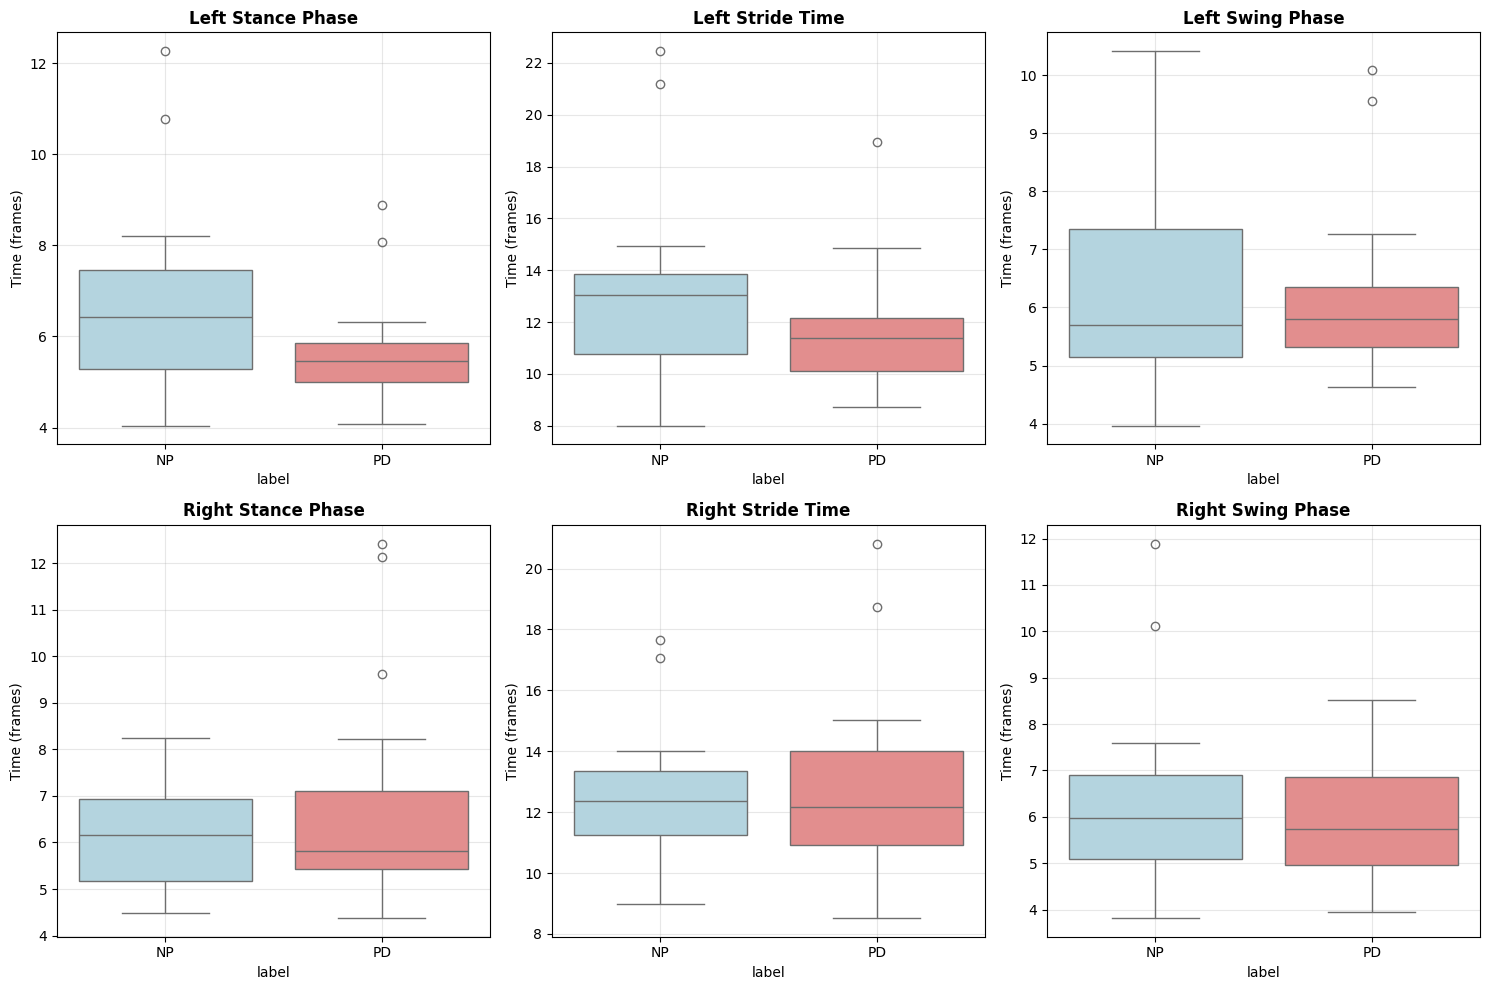

In [42]:
# 8.1 Timing Features Visualization
timing_features = [
    'left_stance_phase', 'left_stride_time', 'left_swing_phase',
    'right_stance_phase', 'right_stride_time', 'right_swing_phase'
]
timing_features = [f for f in timing_features if f in df_features.columns]

if timing_features:
    print("Plotting timing features...")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, feature in enumerate(timing_features):
        ax = axes[i]
        sns.boxplot(data=df_features, x='label', y=feature, ax=ax, 
                    palette=['lightblue', 'lightcoral'])
        ax.set_xticklabels(['NP', 'PD'])
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (frames)')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No timing features available for visualization.")

Plotting symmetry features...


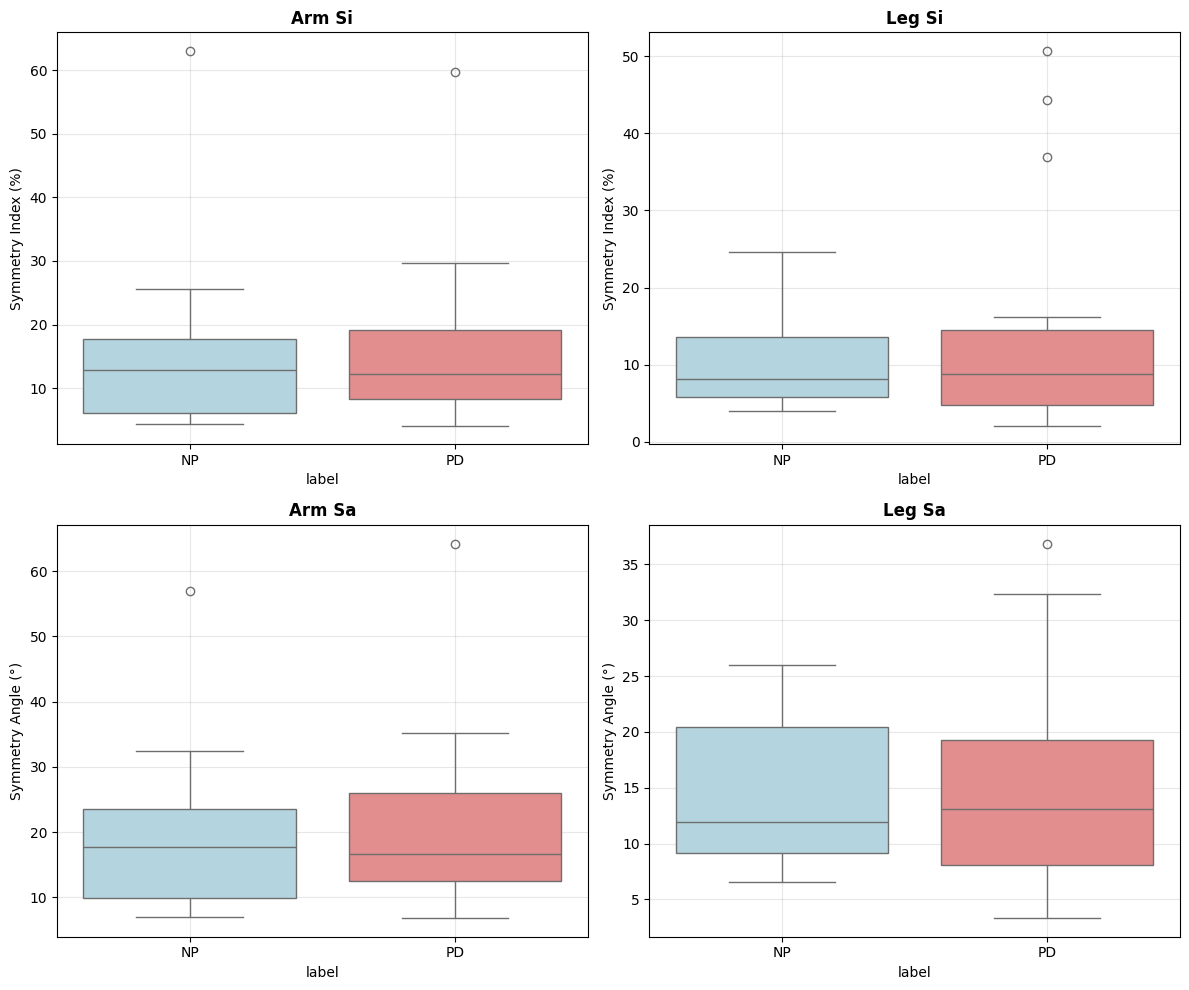

In [43]:
# 8.2 Symmetry Features Visualization
symmetry_features = ['arm_SI', 'leg_SI', 'arm_SA', 'leg_SA']
symmetry_features = [f for f in symmetry_features if f in df_features.columns]

if symmetry_features:
    print("Plotting symmetry features...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, feature in enumerate(symmetry_features):
        ax = axes[i]
        sns.boxplot(data=df_features, x='label', y=feature, ax=ax, 
                    palette=['lightblue', 'lightcoral'])
        ax.set_xticklabels(['NP', 'PD'])
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        if 'SI' in feature:
            ax.set_ylabel('Symmetry Index (%)')
        elif 'SA' in feature:
            ax.set_ylabel('Symmetry Angle (°)')
        else:
            ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No symmetry features available for visualization.")

Plotting spatial features...


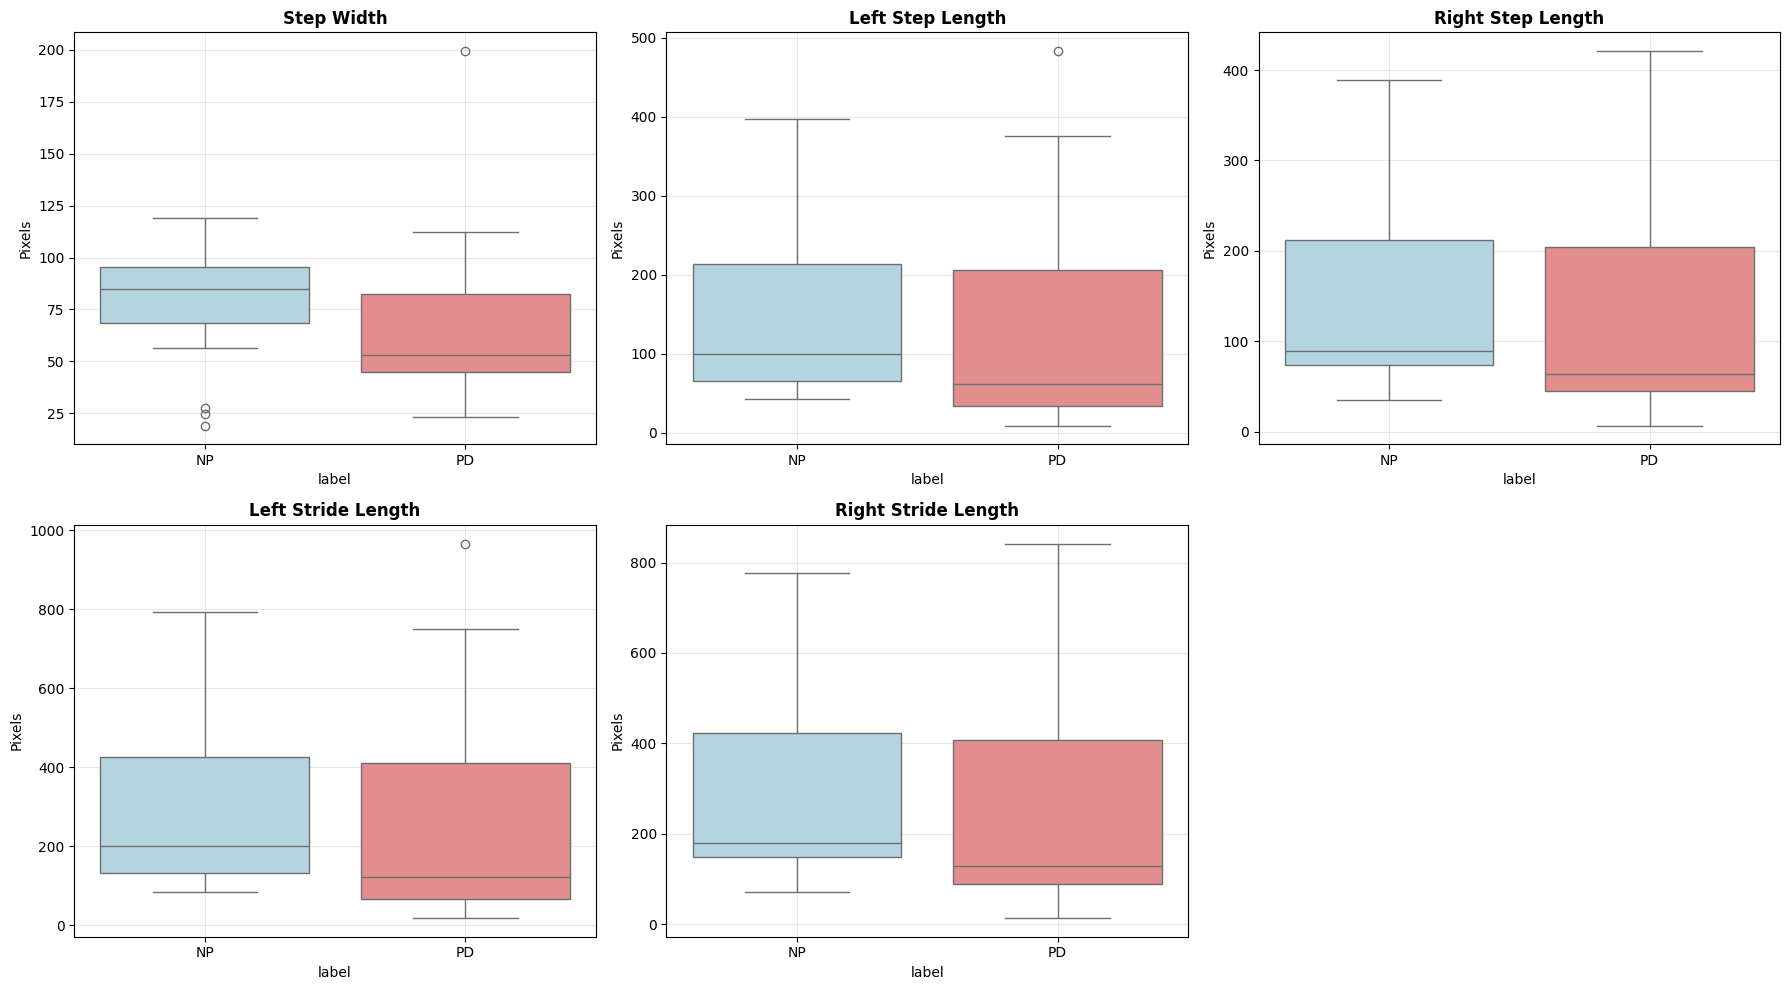

In [44]:
# 8.3 Spatial Features Visualization
spatial_features = ['step_width', 'left_step_length', 'right_step_length', 
                    'left_stride_length', 'right_stride_length']
spatial_features = [f for f in spatial_features if f in df_features.columns]

if spatial_features:
    print("Plotting spatial features...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, feature in enumerate(spatial_features):
        ax = axes[i]
        sns.boxplot(data=df_features, x='label', y=feature, ax=ax, 
                    palette=['lightblue', 'lightcoral'])
        ax.set_xticklabels(['NP', 'PD'])
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_ylabel('Pixels')
        ax.grid(True, alpha=0.3)

    # Hide unused subplot
    for i in range(len(spatial_features), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No spatial features available for visualization.")

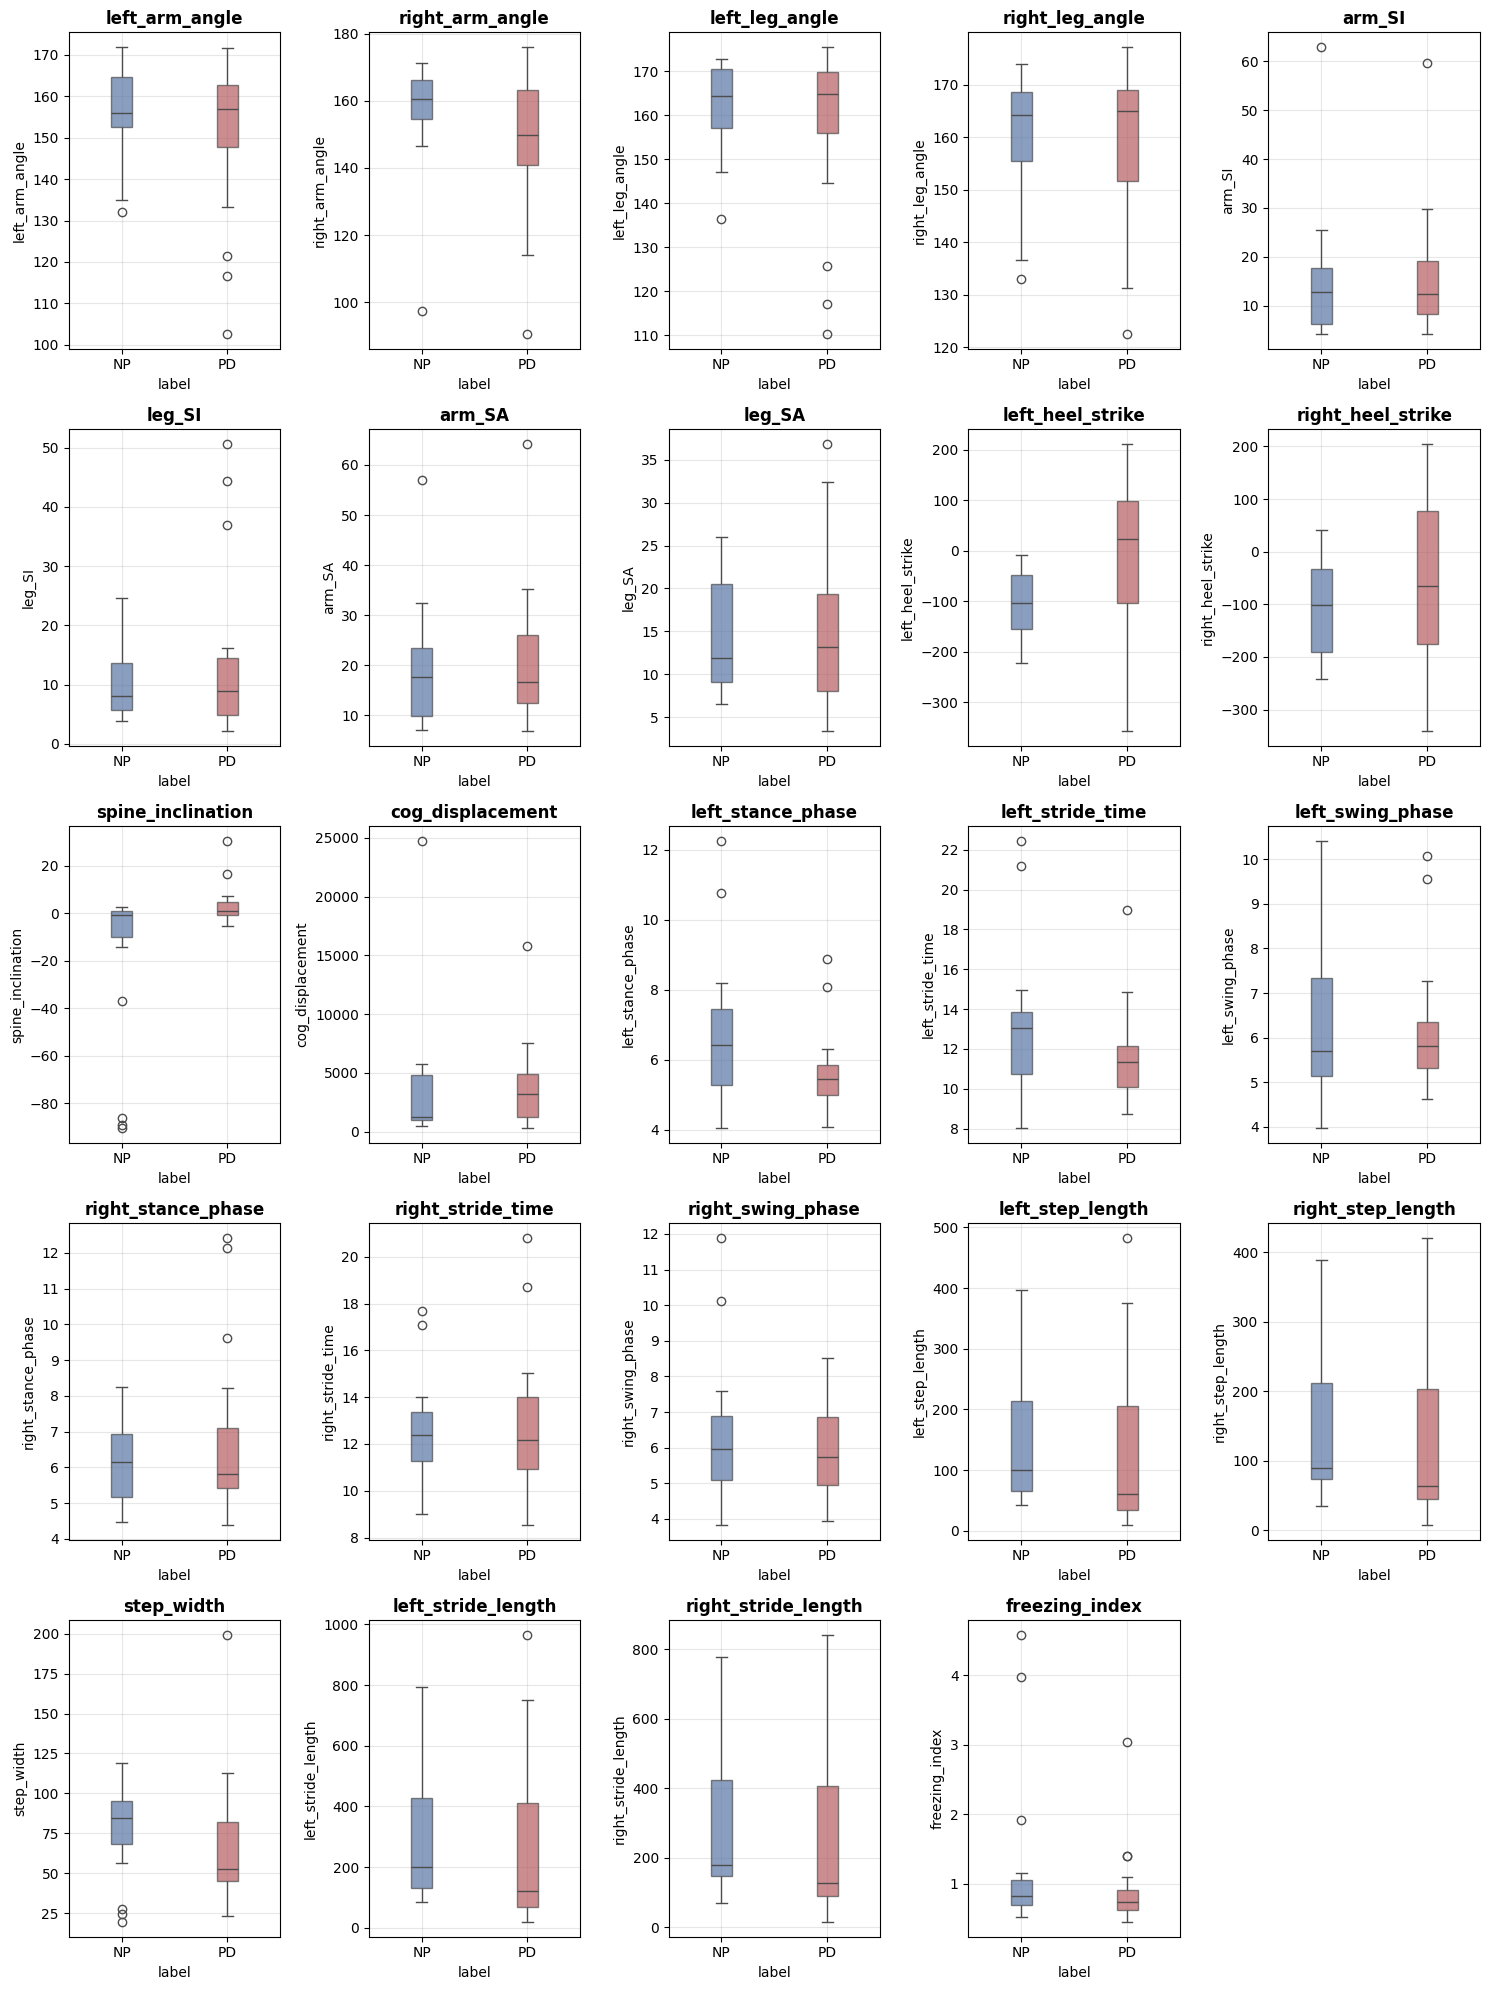

In [45]:
# 8.4 All Features Boxplot (Compact View)
n = len(FEATURE_COLS)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, feat in enumerate(FEATURE_COLS):
    if feat not in df_features.columns:
        continue
    ax = axes[i]
    sns.boxplot(data=df_features, x='label', y=feat, ax=ax, 
                palette=['#4C72B0', '#C44E52'], width=0.2, boxprops=dict(alpha=0.7))
    
    ax.set_xticklabels(['NP', 'PD'])
    ax.set_title(f'{feat}', fontweight='bold')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

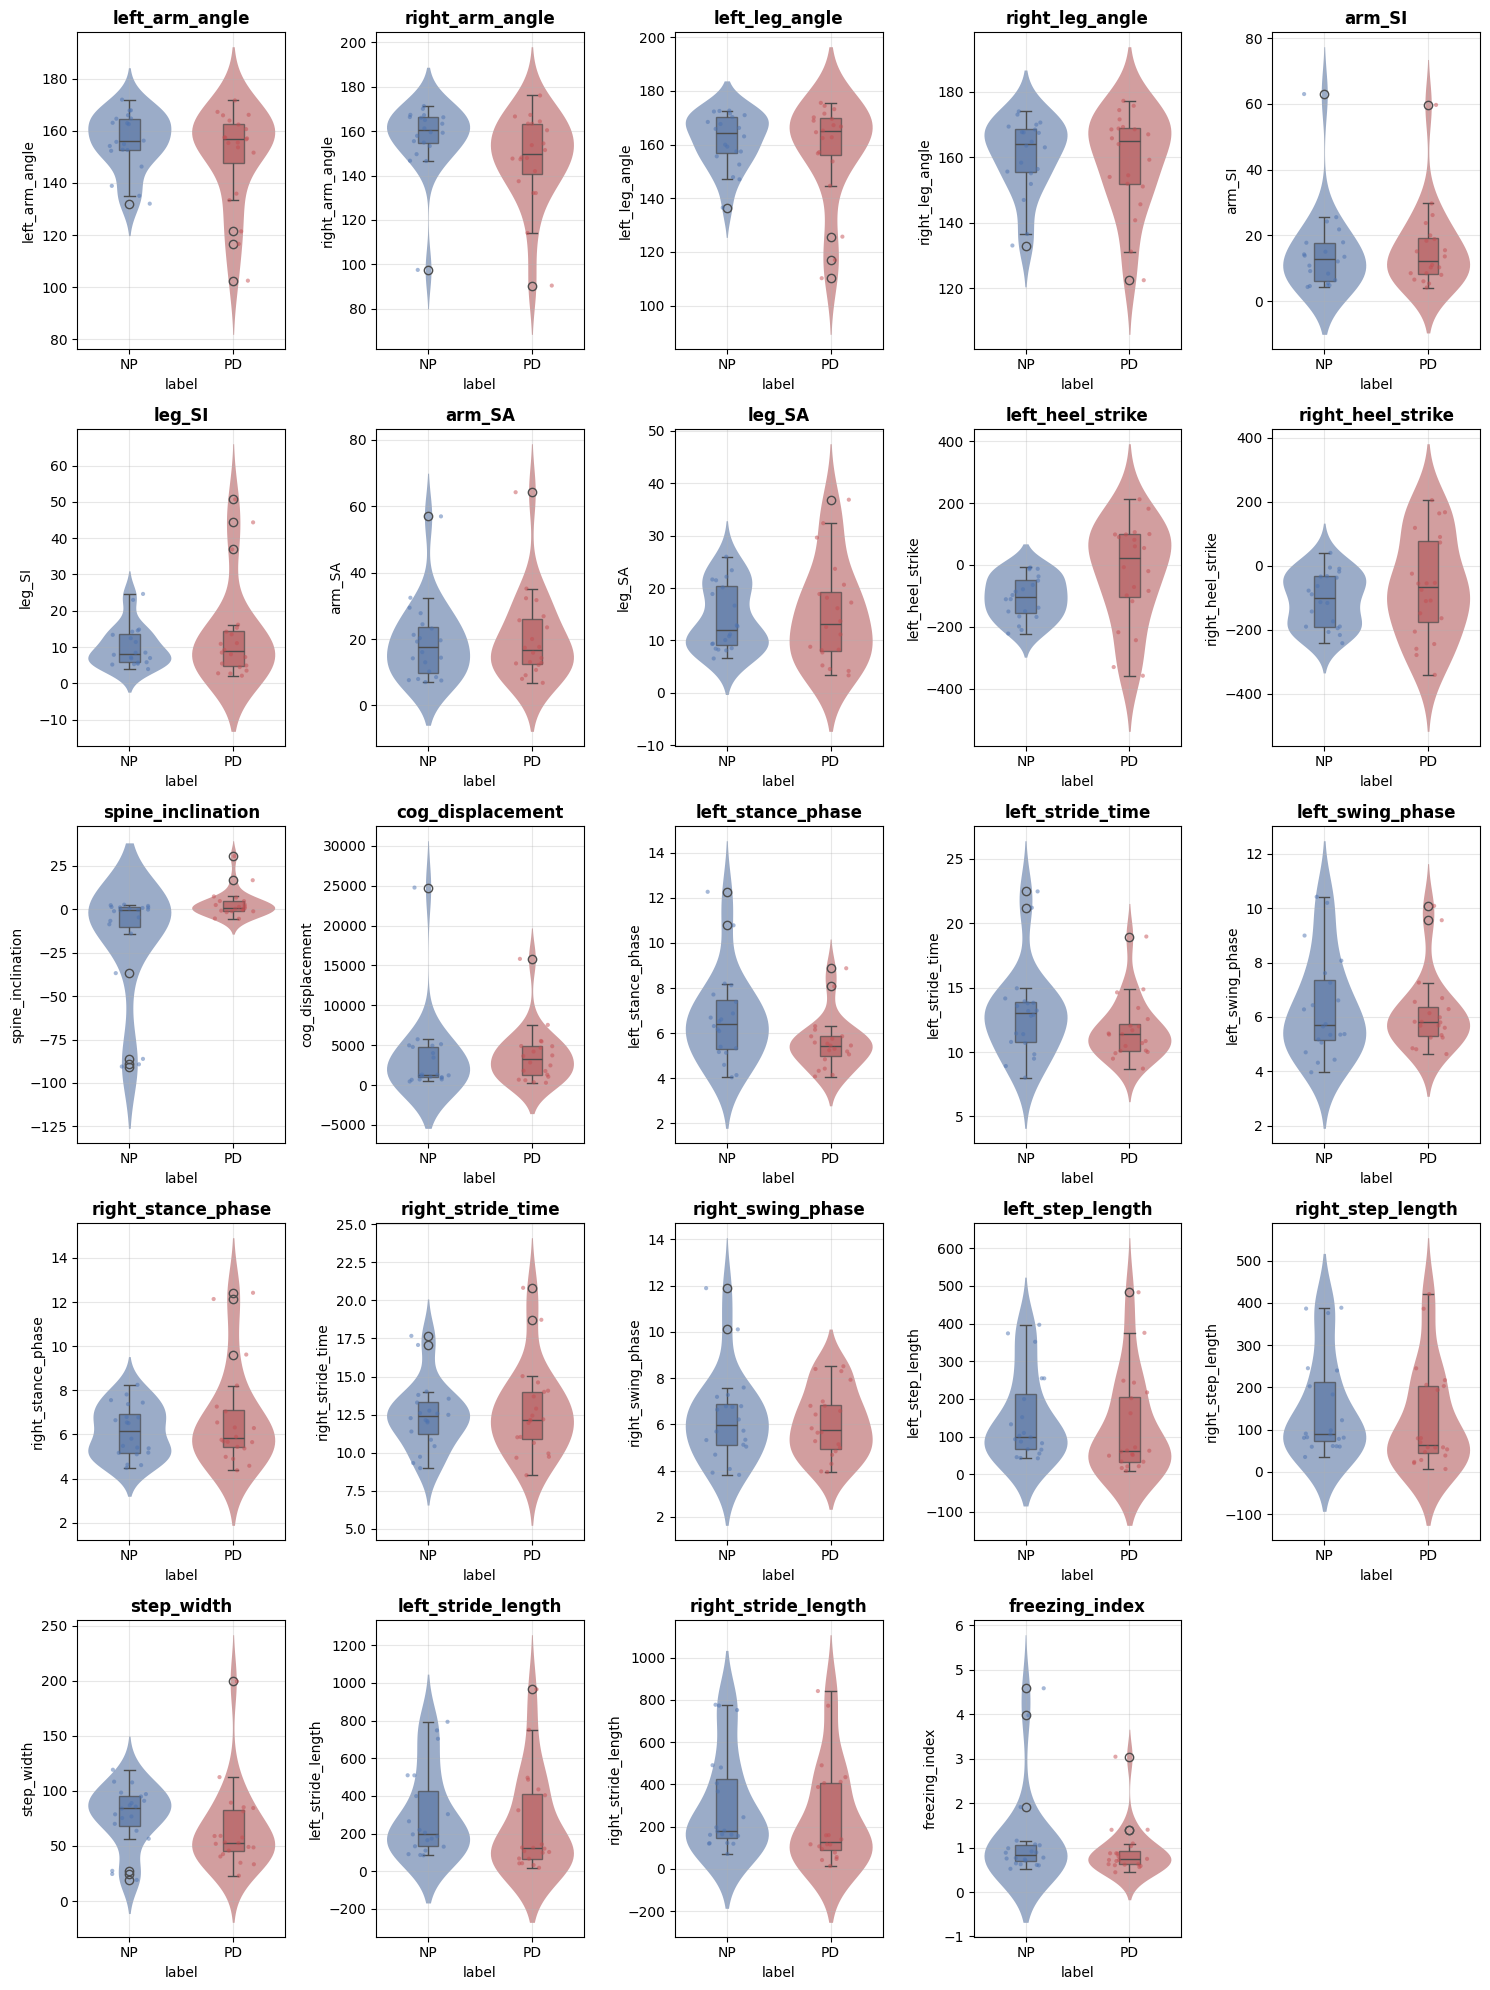

In [46]:
# 8.5 All Features Distribution (Violin + Box + Strip)
n = len(FEATURE_COLS)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, feat in enumerate(FEATURE_COLS):
    if feat not in df_features.columns:
        continue
    ax = axes[i]
    # Violin background
    sns.violinplot(data=df_features, x='label', y=feat, ax=ax, 
                   palette=['#4C72B0', '#C44E52'], inner=None, linewidth=0, alpha=0.6)
    # Box plot
    sns.boxplot(data=df_features, x='label', y=feat, ax=ax, 
                palette=['#4C72B0', '#C44E52'], width=0.2, boxprops=dict(alpha=0.7))
    # Strip plot (individual points)
    sns.stripplot(data=df_features, x='label', y=feat, ax=ax, 
                  jitter=0.2, alpha=0.5, size=3, palette=['#4C72B0', '#C44E52'])
    
    ax.set_xticklabels(['NP', 'PD'])
    ax.set_title(f'{feat}', fontweight='bold')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

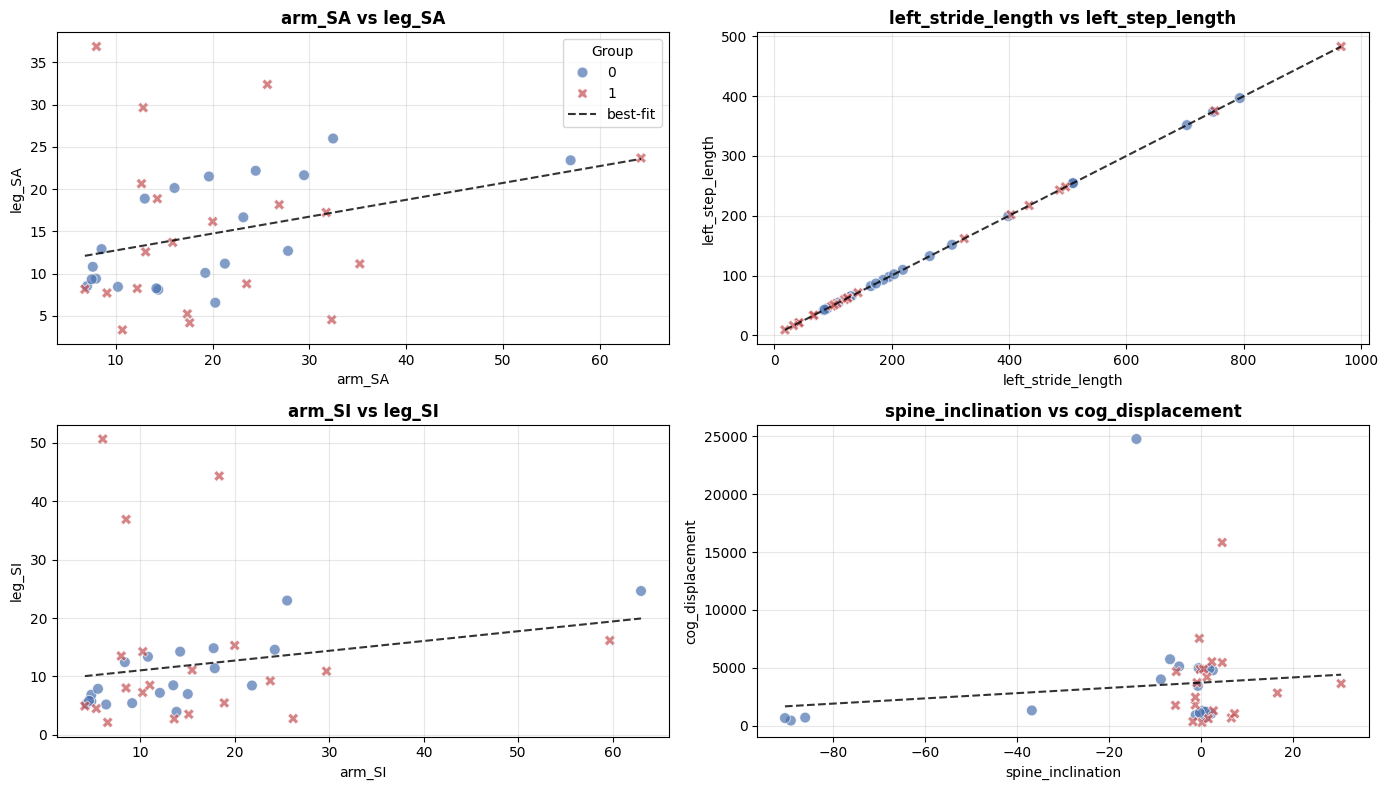

In [47]:
# 8.6 Key Feature Pair Scatter Plots
# Define key feature pairs
key_pairs = [
    ('arm_SA', 'leg_SA'),
    ('left_stride_length', 'left_step_length'),
    ('arm_SI', 'leg_SI'),
    ('spine_inclination', 'cog_displacement')
]

# Filter to only existing columns
key_pairs = [(x, y) for x, y in key_pairs if x in FEATURE_COLS and y in FEATURE_COLS]

if key_pairs:
    n_cols = 2
    n_rows = (len(key_pairs) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    
    # Normalize axes array
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for idx, (x_feat, y_feat) in enumerate(key_pairs):
        ax = axes[idx]
        
        # Skip pair if columns are missing
        if x_feat not in df_features.columns or y_feat not in df_features.columns:
            ax.set_visible(False)
            continue

        # Scatter plot
        sns.scatterplot(
            data=df_features,
            x=x_feat, y=y_feat,
            hue='label',
            palette=['#4C72B0', '#C44E52'],
            style='label',
            s=60,
            alpha=0.7,
            ax=ax
        )
        
        # Compute best-fit line
        xv = df_features[x_feat].values
        yv = df_features[y_feat].values
        valid = np.isfinite(xv) & np.isfinite(yv)
        if np.sum(valid) >= 2:
            m, b = np.polyfit(xv[valid], yv[valid], 1)
            lx = np.linspace(np.min(xv[valid]), np.max(xv[valid]), 100)
            ly = m * lx + b
            ax.plot(lx, ly, 'k--', lw=1.5, alpha=0.8, label='best-fit')
        
        # Title and labels
        ax.set_title(f"{x_feat} vs {y_feat}", fontweight='bold')
        ax.set_xlabel(x_feat)
        ax.set_ylabel(y_feat)
        ax.grid(True, alpha=0.3)
        
        # Legend only on first subplot
        if idx == 0:
            ax.legend(title='Group', loc='best')
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

    # Hide unused subplots
    for j in range(len(key_pairs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No key feature pairs available for visualization.")

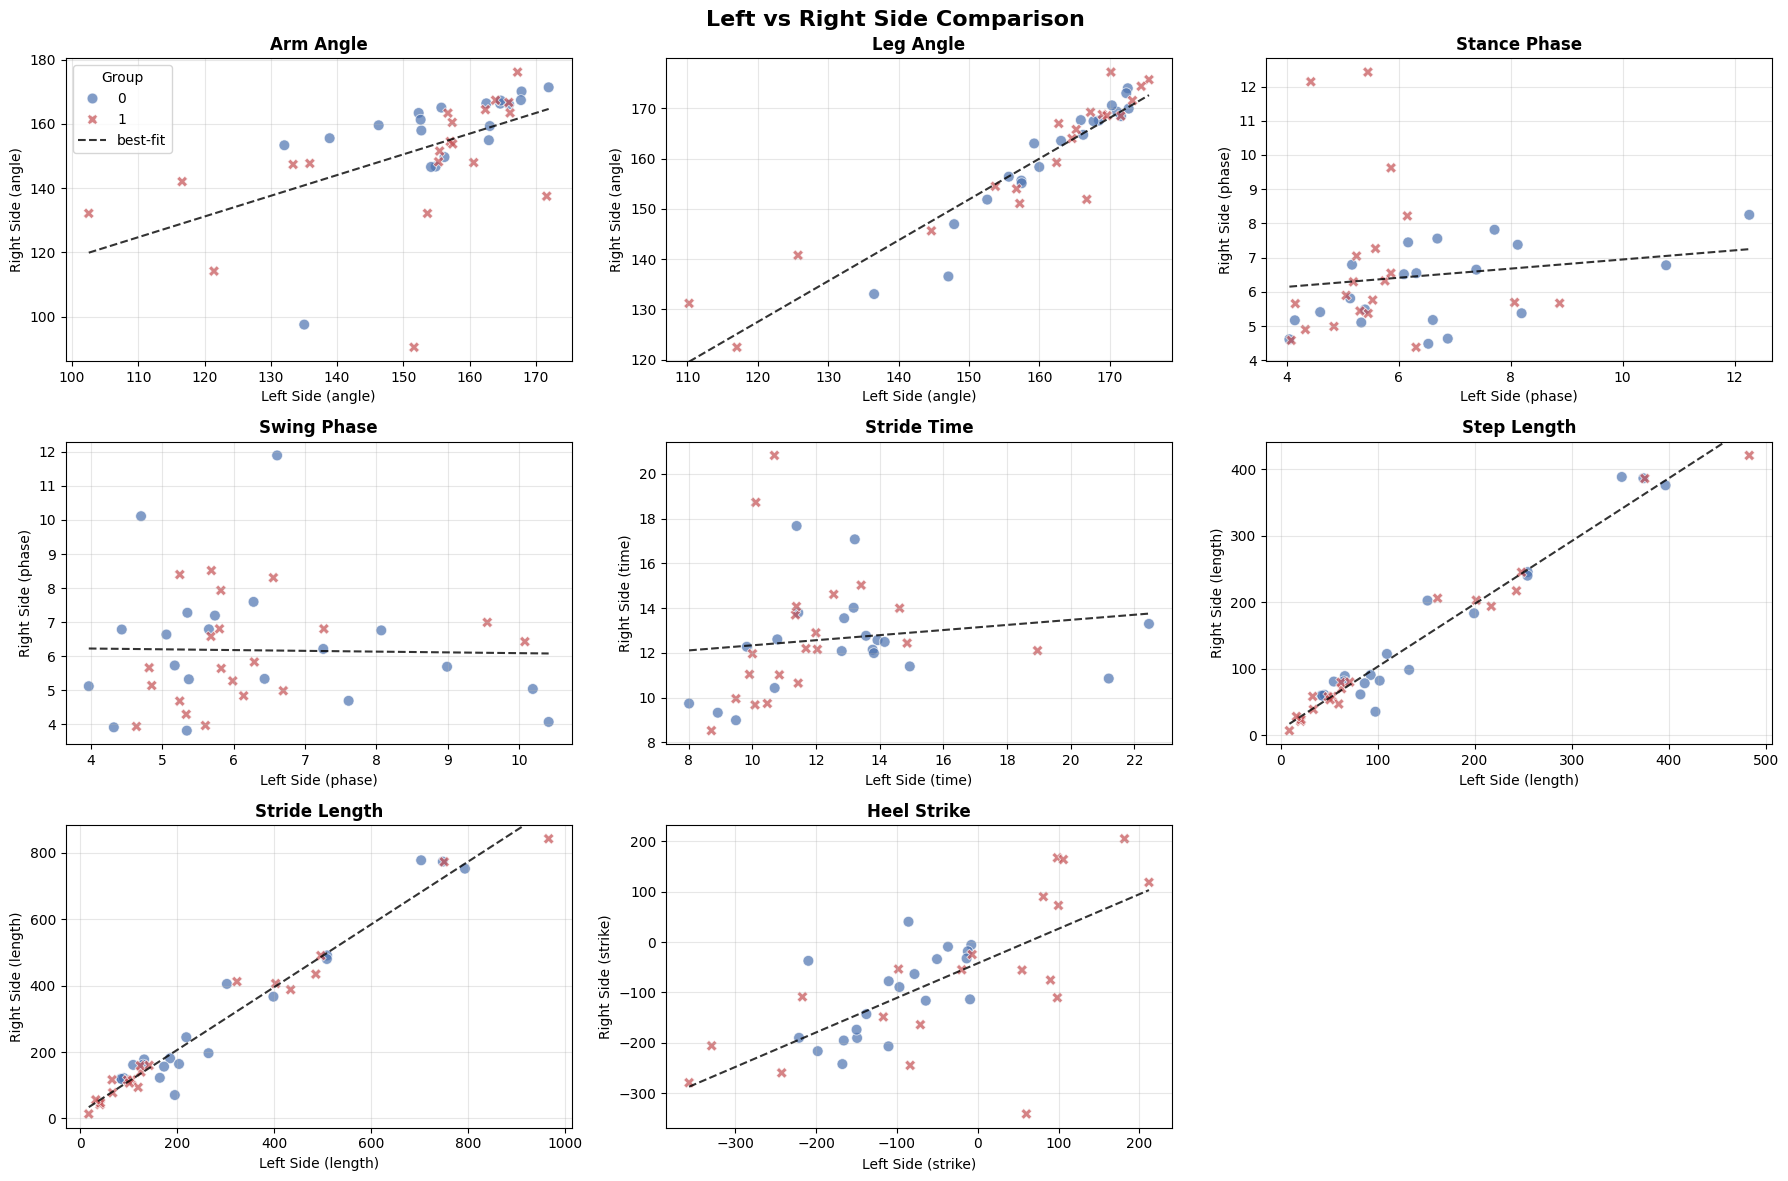

In [48]:
# 8.7 Left vs Right Side Analysis
# Define feature pairs for temporal gait features
feature_pairs = [
    ('left_arm_angle', 'right_arm_angle', 'Arm Angle'),
    ('left_leg_angle', 'right_leg_angle', 'Leg Angle'),
    ('left_stance_phase', 'right_stance_phase', 'Stance Phase'),
    ('left_swing_phase', 'right_swing_phase', 'Swing Phase'),
    ('left_stride_time', 'right_stride_time', 'Stride Time'),
    ('left_step_length', 'right_step_length', 'Step Length'),
    ('left_stride_length', 'right_stride_length', 'Stride Length'),
    ('left_heel_strike', 'right_heel_strike', 'Heel Strike')
]

# Filter existing features
feature_pairs = [
    (x, y, t) for x, y, t in feature_pairs 
    if x in FEATURE_COLS and y in FEATURE_COLS
]

if feature_pairs:
    n = len(feature_pairs)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    fig.suptitle("Left vs Right Side Comparison", fontsize=16, fontweight='bold')

    for i, (x_col, y_col, title) in enumerate(feature_pairs):
        ax = axes[i]
        
        # Skip pair if columns are missing
        if x_col not in df_features.columns or y_col not in df_features.columns:
            ax.set_visible(False)
            continue

        # Scatter plot
        sns.scatterplot(
            data=df_features,
            x=x_col, y=y_col,
            hue='label',
            palette=['#4C72B0', '#C44E52'],
            style='label',
            s=60,
            alpha=0.7,
            ax=ax
        )
        
        # Best-fit line
        xv = df_features[x_col].values
        yv = df_features[y_col].values
        valid = np.isfinite(xv) & np.isfinite(yv)
        if np.sum(valid) >= 2:
            m, b = np.polyfit(xv[valid], yv[valid], 1)
            lx = np.linspace(np.nanmin(xv[valid]), np.nanmax(xv[valid]), 100)
            ly = m * lx + b
            ax.plot(lx, ly, 'k--', lw=1.5, alpha=0.8, label='best-fit')
        
        # Axis limits with padding
        if np.sum(valid) >= 1:
            xmin_data, xmax_data = np.nanmin(xv[valid]), np.nanmax(xv[valid])
            ymin_data, ymax_data = np.nanmin(yv[valid]), np.nanmax(yv[valid])
            pad_x = (xmax_data - xmin_data) * 0.05 if xmax_data != xmin_data else 0.5
            pad_y = (ymax_data - ymin_data) * 0.05 if ymax_data != ymin_data else 0.5
            ax.set_xlim(xmin_data - pad_x, xmax_data + pad_x)
            ax.set_ylim(ymin_data - pad_y, ymax_data + pad_y)

        # Title and labels
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(f'Left Side ({x_col.split("_")[-1]})')
        ax.set_ylabel(f'Right Side ({y_col.split("_")[-1]})')
        ax.grid(True, alpha=0.3)
        
        # Legend only once
        if i == 0:
            ax.legend(title='Group', loc='upper left')
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

    # Hide unused subplots
    for j in range(len(feature_pairs), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No left/right feature pairs available for visualization.")

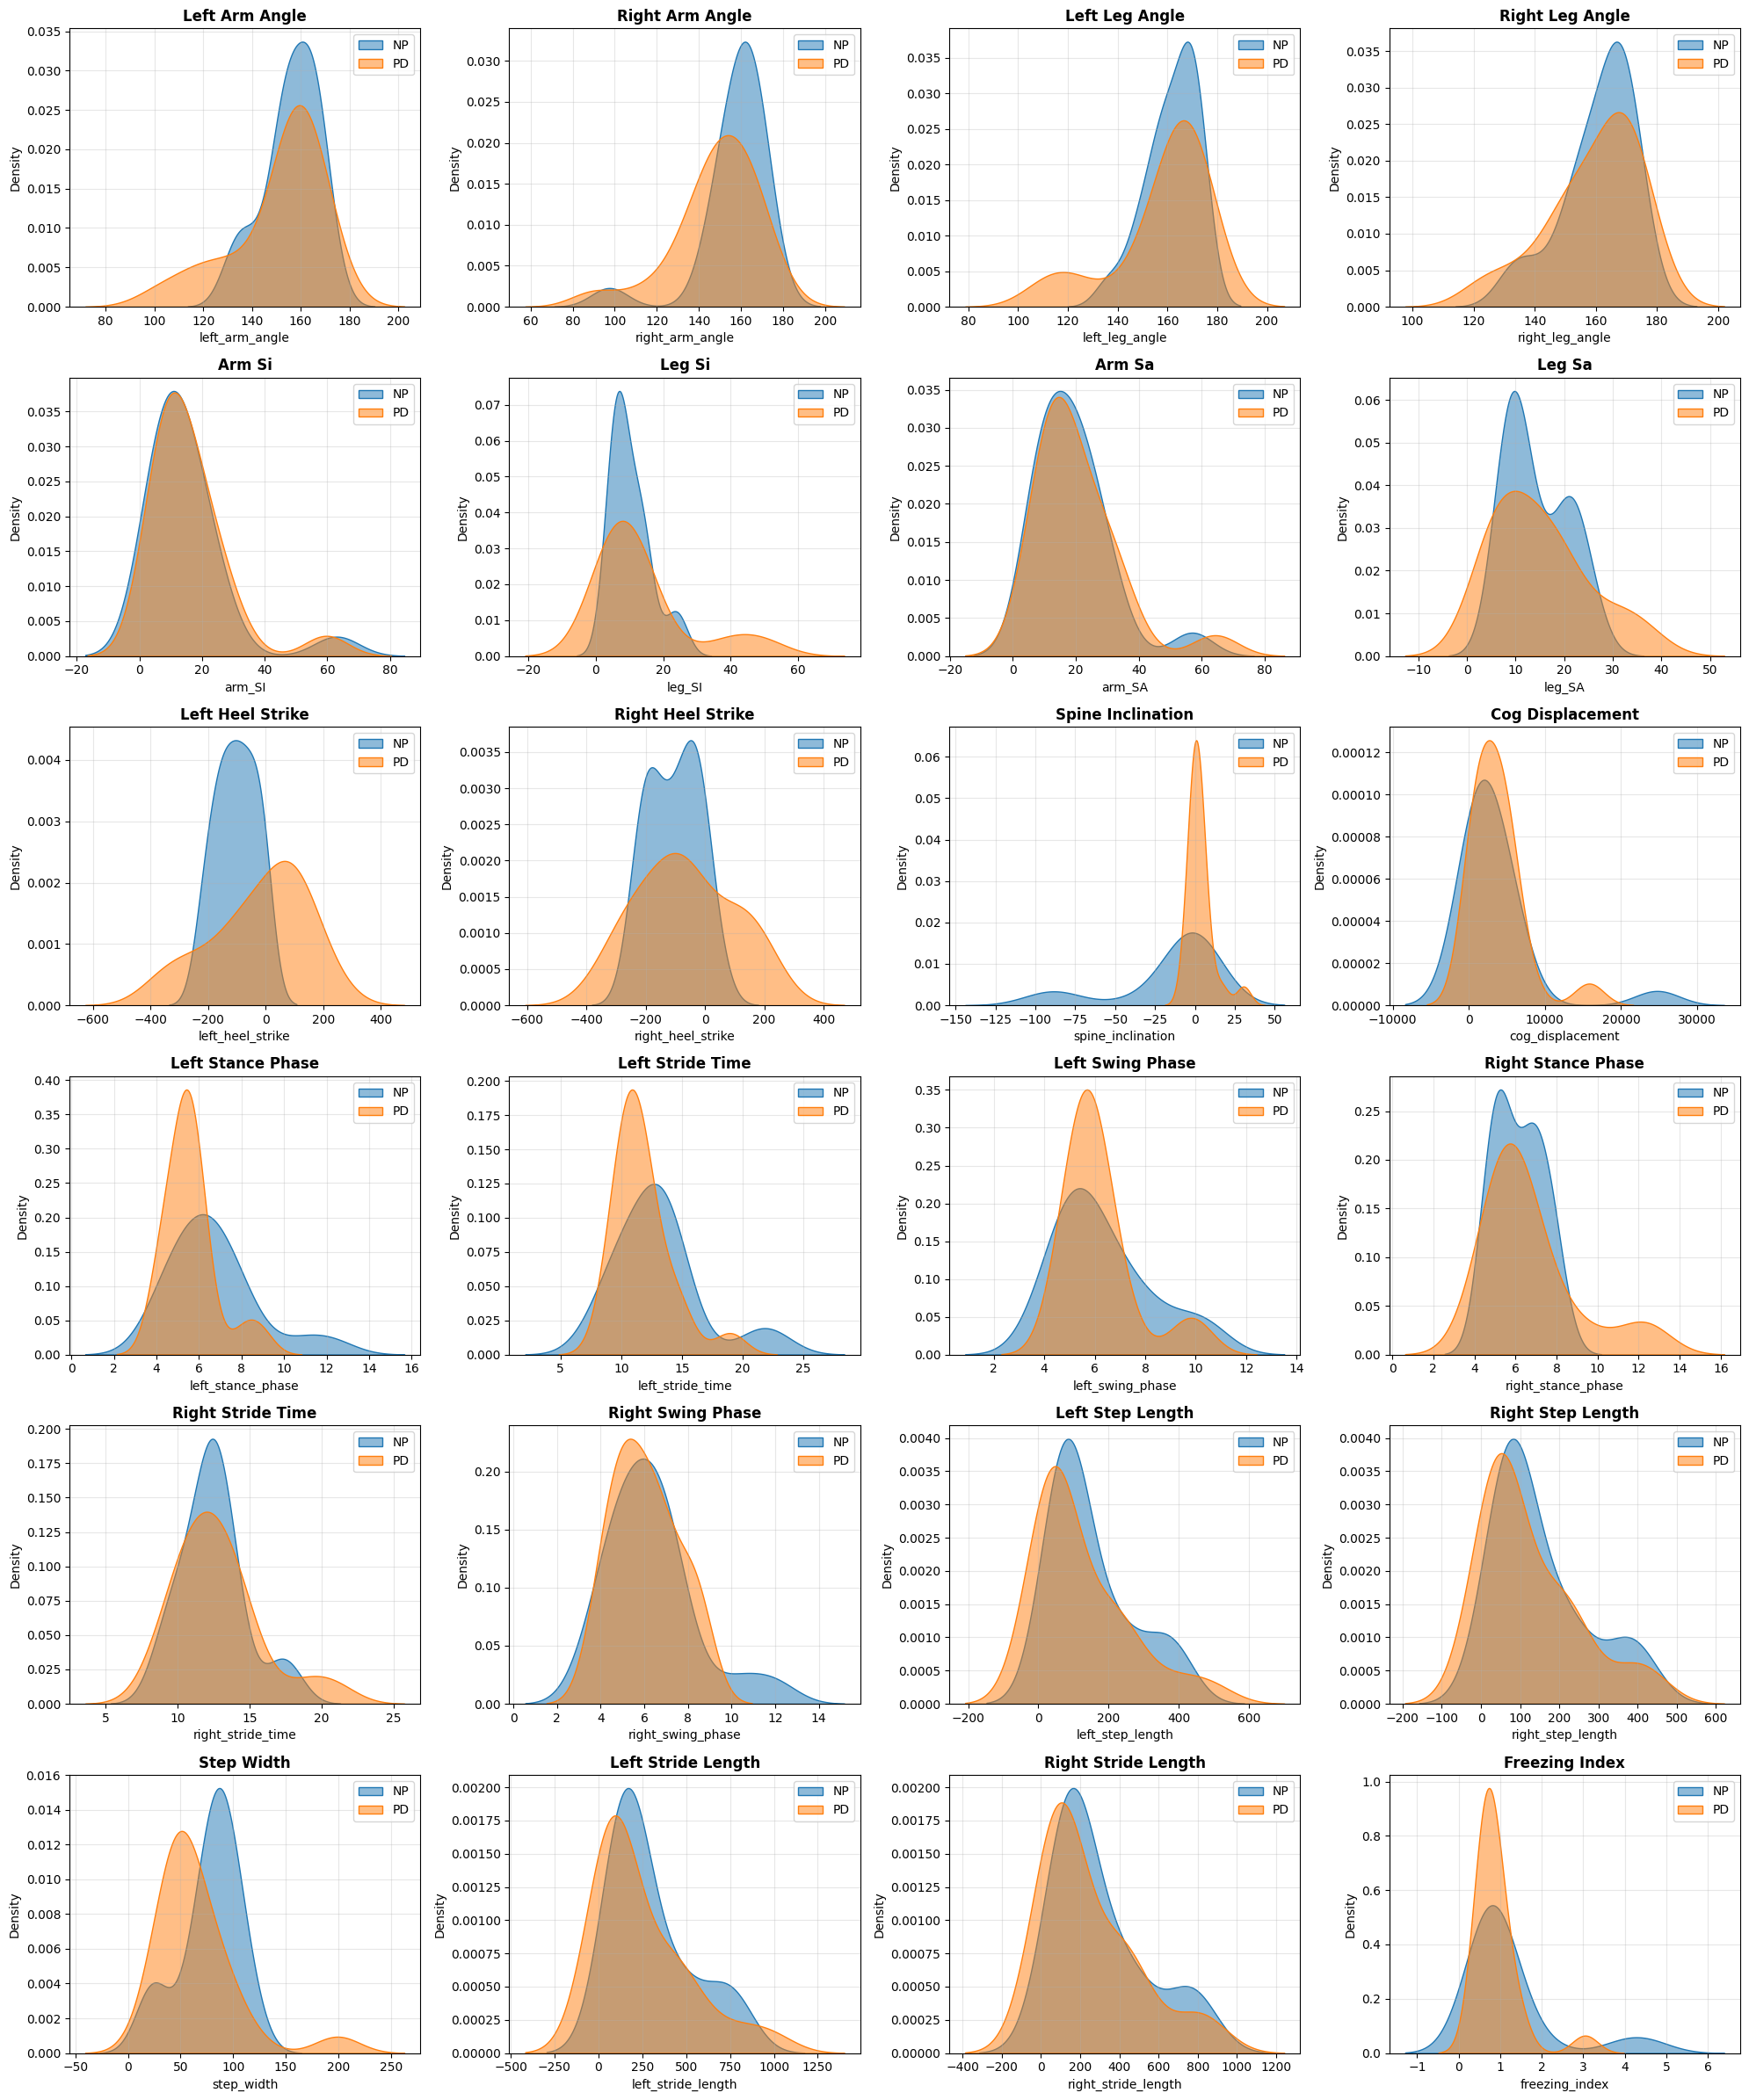

In [49]:
# 8.8 KDE Plots (NP vs PD Density Comparison)
df_np = df_features[df_features['label'] == 0]
df_pd = df_features[df_features['label'] == 1]

n_features = len(FEATURE_COLS)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(FEATURE_COLS):
    if feature not in df_features.columns:
        continue
        
    ax = axes[i]
    
    # Plot KDEs
    try:
        sns.kdeplot(data=df_np, x=feature, label='NP', fill=True, alpha=0.5, ax=ax)
        sns.kdeplot(data=df_pd, x=feature, label='PD', fill=True, alpha=0.5, ax=ax)
        
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    except:
        ax.text(0.5, 0.5, f"KDE failed for {feature}", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()

# Hide unused axes
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

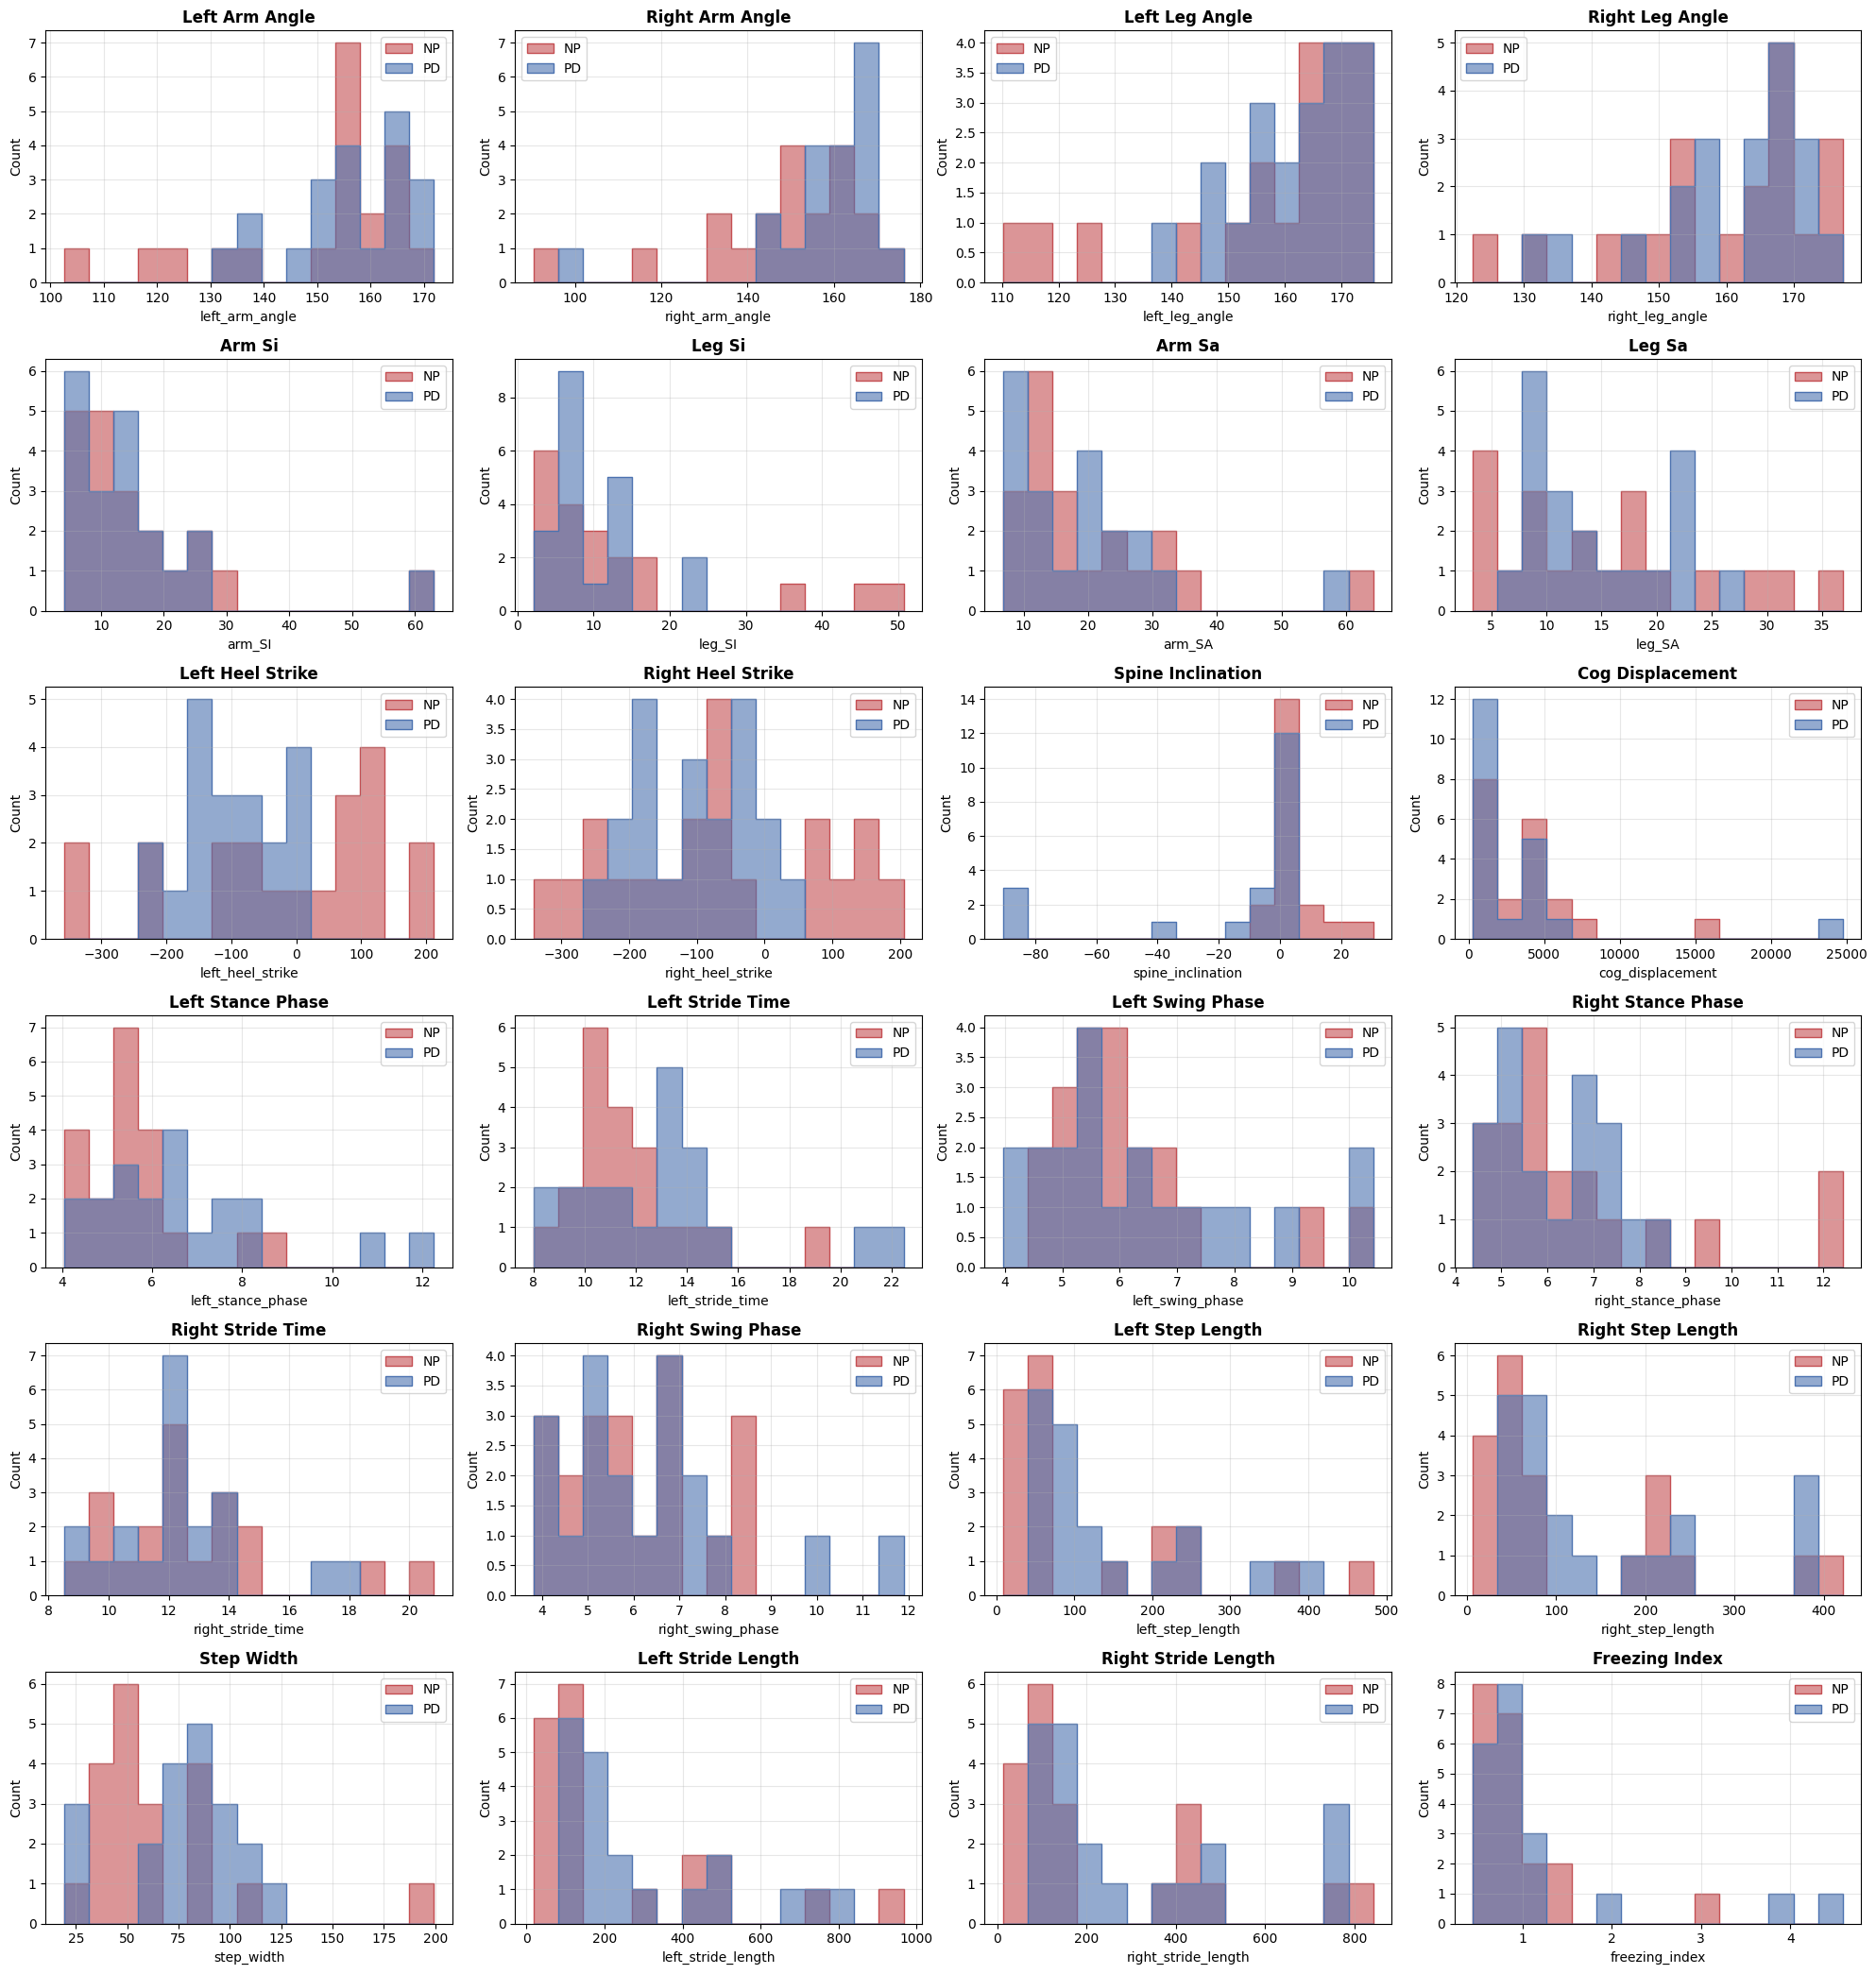

In [50]:
# 8.9 Histograms (NP vs PD)
n = len(FEATURE_COLS)
if n == 0:
    print("No features available for histograms.")
else:
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, feat in enumerate(FEATURE_COLS):
        if feat not in df_features.columns:
            axes[i].axis('off')
            continue

        ax = axes[i]
        data = df_features[[feat, 'label']].dropna()
        if data.empty:
            ax.text(0.5, 0.5, f"No data for {feat}", ha='center', va='center')
            ax.set_axis_off()
            continue

        # Plot histograms for each class
        sns.histplot(data=data, x=feat, hue='label', bins=15,  # Reduced bins for clarity
                     palette=['#4C72B0', '#C44E52'], alpha=0.6, 
                     element='step', stat='count', ax=ax)
        ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)
        ax.legend(labels=['NP', 'PD'])

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [51]:
# 8.10 Summary Statistics
# Compute summary statistics
summary_stats = df_features[FEATURE_COLS].agg(['min', 'max', 'mean', 'std']).T
summary_stats['range'] = summary_stats['max'] - summary_stats['min']

# Add group-wise statistics
for label_name, label_val in [('NP', 0), ('PD', 1)]:
    group_data = df_features[df_features['label'] == label_val][FEATURE_COLS]
    summary_stats[f'{label_name}_mean'] = group_data.mean()
    summary_stats[f'{label_name}_std'] = group_data.std()

# Create a cleaner display version for the notebook
display_df = summary_stats[['min', 'max', 'mean', 'std', 'NP_mean', 'PD_mean']].copy()
display_df.columns = ['Min', 'Max', 'Overall Mean', 'Overall Std', 'NP Mean', 'PD Mean']
display_df.index.name = 'Feature'

print("\nFeature Statistics Table:")
display(display_df)


Feature Statistics Table:


,Min,Max,Overall Mean,Overall Std,NP Mean,PD Mean
Feature,,,,,,
left_arm_angle,102.536048,171.927579,153.362884,15.467454,156.107322,150.618446
right_arm_angle,90.443358,176.091867,152.653215,18.441136,157.265898,148.040531
left_leg_angle,110.239517,175.566045,159.842508,15.176924,161.786809,157.898207
right_leg_angle,122.431450,177.246389,159.878361,13.256462,160.673487,159.083235
arm_SI,4.135701,63.007726,15.428721,12.697041,14.885727,15.971716
leg_SI,2.118527,50.676633,11.946126,10.674892,10.286564,13.605688
arm_SA,6.821563,64.239900,19.794001,12.450479,19.071688,20.516315
leg_SA,3.340787,36.873768,14.699108,8.078908,14.334059,15.064157
left_heel_strike,-357.349401,211.860780,-63.463271,130.489982,-103.874511,-23.052032
